# OncoBridge-MMCAT v5 — Final Research-Grade Drug Response Prediction

## What every published paper uses as metrics:
| Paper | PCC | Spearman | RMSE | R² | AUC | AUPR |
|-------|-----|----------|------|----|-----|------|
| DeepCDR (2020) | ✓ | ✓ | ✓ | – | ✓ | ✓ |
| DRN-CDR (2024) | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |
| PASO (2025) | ✓ | – | ✓ | ✓ | – | – |
| DTLCDR (2025) | ✓ | ✓ | – | ✓ | – | – |
| GraphDRP (2022) | ✓ | ✓ | ✓ | – | – | – |
| **OncoBridge v5** | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |

## v5 improvements over v4:
| # | Change | Why |
|---|--------|-----|
| 1 | **Dual drug encoder**: ChemBERTa (768→256) + Morgan FP (2048→256) concatenated → 512-dim | v4 warm RMSE regressed from 0.9249→1.002 because ChemBERTa alone is optimized for generalization not memorization. Morgan FP recovers precision on seen drugs. |
| 2 | **Modality dropout raised to p=0.35** | v4 ablation showed mutation still contributed nothing (Δ=−0.0196 going wrong direction). Stronger dropout forces genuine multi-omics learning. |
| 3 | **Added AUPR metric** | DeepCDR and DRN-CDR both report AUPR. Required to match their evaluation protocol exactly. |
| 4 | **Per-drug Pearson box plot** | DRN-CDR Fig 9 style — shows distribution of per-drug PCC across all methods for direct comparison. |
| 5 | **Scatter plots for top/bottom drugs** | DRN-CDR Fig 6 style — shows best and worst predicted drugs with observed vs predicted scatter. |
| 6 | **TCGA cancer-type correlation table** | DRN-CDR Table 9 style — per-cancer-type PCC across all 15+ TCGA types. |


In [1]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 1 — IMPORTS, SETUP & CONFIG
# ═══════════════════════════════════════════════════════════════════════
import os, gc, json, math, time, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.checkpoint import checkpoint as grad_checkpoint

from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    mean_squared_error, r2_score, precision_recall_curve
)

try:
    from transformers import AutoTokenizer, AutoModel
    print('transformers installed')
except ImportError:
    os.system('pip install transformers -q')
    from transformers import AutoTokenizer, AutoModel

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size']  = 11
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_theme(style='whitegrid')

def section(t):
    print('\n' + '═'*70)
    print(f'  {t}')
    print('═'*70)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_GPUS = torch.cuda.device_count()
print(f'Device: {DEVICE} | GPUs: {N_GPUS}')
for i in range(N_GPUS):
    print(f'  GPU {i}: {torch.cuda.get_device_name(i)} | '
          f'{torch.cuda.get_device_properties(i).total_memory/1e9:.1f} GB')

DATA_BASE = '/kaggle/input/smiles-data'
CKPT_PATH = '/kaggle/input/models/proutkarshtiwari/oncobridgev7-95-74acc/pytorch/default/1/oncobridge_v7_best.pt'
OUT_DIR   = '/kaggle/working/'

PATH_MRNA       = f'{DATA_BASE}/ccle_mrna_scaled.parquet'
PATH_CNV        = f'{DATA_BASE}/ccle_cnv_scaled.parquet'
PATH_MUT        = f'{DATA_BASE}/ccle_mut_scaled.parquet'
PATH_METH       = f'{DATA_BASE}/ccle_meth_scaled.parquet'
PATH_IC50_WARM  = f'{DATA_BASE}/ic50_warm.parquet'
PATH_IC50_COLD  = f'{DATA_BASE}/ic50_cold.parquet'
PATH_SPLITS     = f'{DATA_BASE}/ccle_splits.json'
PATH_FP_MATRIX  = f'{DATA_BASE}/drug_fp_matrix.npy'
PATH_DRUG_NAMES = f'{DATA_BASE}/valid_drug_names.csv'
PATH_COLD_DRUGS = f'{DATA_BASE}/cold_start_drugs.json'
PATH_SMILES     = f'{DATA_BASE}/drug_smiles_cache.csv'

CONFIG = {
    # Backbone — must match Phase 1 exactly
    'num_mrna_genes': 8011,
    'num_cnv_genes':  3500,
    'num_mut_genes':  2500,
    'num_meth_genes': 6000,
    'embed_dim':          384,
    'num_heads':          8,
    'num_encoder_layers': 6,
    'num_cross_layers':   4,
    'cnn_kernel':         16,
    'cnn_stride':         16,
    'ff_dim':             1536,
    'dropout':            0.20,
    'gate_init':          1.5,
    'use_grad_ckpt':      False,
    'num_classes':        22,

    # v5 CHANGE 1: Dual drug encoder
    # ChemBERTa (768-dim CLS → 256) + Morgan FP (2048-bit → 256) = 512-dim combined
    # ChemBERTa generalizes to unseen drugs (cold-start)
    # Morgan FP memorizes seen drug structures precisely (warm accuracy)
    'chemberta_model':   'seyonec/ChemBERTa-zinc-base-v1',
    'chemberta_dim':     768,
    'chemberta_out':     256,   # ChemBERTa projection output
    'fp_bits':           2048,
    'fp_hidden':         512,
    'fp_out':            256,   # Morgan FP encoder output
    # combined drug dim = chemberta_out + fp_out = 512

    # v5 CHANGE 2: Modality dropout raised from 0.20 to 0.35
    # v4 ablation: removing mutation IMPROVED AvgDrugPCC by 0.02
    # = mutation still contributing nothing. Stronger dropout needed.
    'modality_dropout_p': 0.35,

    'batch_size':    64,
    'grad_accum':    4,
    'num_workers':   4,
    'use_amp':       True,
    'clip_grad':     1.0,
    'warmup_frac':   0.15,

    'stage1_epochs':   30,
    'stage1_lr':       1e-3,
    'stage1_wd':       1e-4,
    'stage1_patience': 8,

    'stage2_unfreeze_n_cross': 2,
    'stage2_epochs':     40,
    'stage2_lr_head':    1e-4,
    'stage2_lr_cross':   5e-5,
    'stage2_wd':         1e-4,
    'stage2_patience':   10,

    'checkpoint_ft': 'oncobridge_drug_response_v5_best.pt',
}

# combined drug embedding dim used downstream
CONFIG['drug_embed_dim'] = CONFIG['chemberta_out'] + CONFIG['fp_out']  # 512

print(f'\nOncoBridge v5')
print(f'Drug encoder: ChemBERTa({CONFIG["chemberta_out"]}) + MorganFP({CONFIG["fp_out"]}) = {CONFIG["drug_embed_dim"]}-dim')
print(f'Modality dropout: p={CONFIG["modality_dropout_p"]} (raised from v4 0.20)')
print(f'Stage 2: last {CONFIG["stage2_unfreeze_n_cross"]} cross-layers unfrozen')
print(f'Effective batch: {CONFIG["batch_size"]} x {CONFIG["grad_accum"]} = {CONFIG["batch_size"]*CONFIG["grad_accum"]}')


transformers installed
Device: cuda | GPUs: 2
  GPU 0: Tesla T4 | 15.6 GB
  GPU 1: Tesla T4 | 15.6 GB

OncoBridge v5
Drug encoder: ChemBERTa(256) + MorganFP(256) = 512-dim
Modality dropout: p=0.35 (raised from v4 0.20)
Stage 2: last 2 cross-layers unfrozen
Effective batch: 64 x 4 = 256


In [2]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 2 — LOAD DATA
# ═══════════════════════════════════════════════════════════════════════
section('2. LOAD DATA')

t0 = time.time()
mrna_df   = pd.read_parquet(PATH_MRNA)
cnv_df    = pd.read_parquet(PATH_CNV)
mut_df    = pd.read_parquet(PATH_MUT)
meth_df   = pd.read_parquet(PATH_METH)
ic50_warm = pd.read_parquet(PATH_IC50_WARM)
ic50_cold = pd.read_parquet(PATH_IC50_COLD)
print(f'Loaded in {time.time()-t0:.1f}s')
print(f'mRNA {mrna_df.shape} | CNV {cnv_df.shape} | Mut {mut_df.shape} | Meth {meth_df.shape}')
print(f'IC50 warm: {len(ic50_warm):,} | cold: {len(ic50_cold):,}')

with open(PATH_SPLITS) as f: splits = json.load(f)
cl_train = splits['train']; cl_val = splits['val']; cl_test = splits['test']
print(f'Cell lines: Train={len(cl_train)} Val={len(cl_val)} Test={len(cl_test)}')

FP_MATRIX  = np.load(PATH_FP_MATRIX).astype(np.float32)  # (n_drugs, 2048)
DRUG_NAMES = pd.read_csv(PATH_DRUG_NAMES, header=None)[0].tolist()
drug2idx   = {d: i for i, d in enumerate(DRUG_NAMES)}
id_to_drug = {i: d for d, i in drug2idx.items()}
n_drugs    = len(DRUG_NAMES)
print(f'Drugs: {n_drugs} | FP_MATRIX: {FP_MATRIX.shape}')

smiles_df   = pd.read_csv(PATH_SMILES)
drug2smiles = dict(zip(smiles_df['drug_name'], smiles_df['smiles']))
SMILES_LIST = [drug2smiles.get(d, 'C') for d in DRUG_NAMES]
n_missing   = sum(1 for s in SMILES_LIST if s == 'C')
print(f'SMILES: {len(SMILES_LIST)-n_missing}/{len(SMILES_LIST)} drugs have SMILES')

with open(PATH_COLD_DRUGS) as f: cold_info = json.load(f)
cold_start_drugs = set(cold_info['cold_start'])

all_cell_lines = sorted(mrna_df.index.tolist())
cl_to_idx = {cl: i for i, cl in enumerate(all_cell_lines)}

for df in [ic50_warm, ic50_cold]:
    df['cl_idx']   = df['ModelID'].map(cl_to_idx)
    df['drug_idx'] = df['DRUG_NAME'].map(drug2idx)

ic50_warm = ic50_warm.dropna(subset=['cl_idx','drug_idx'])
ic50_warm['cl_idx']   = ic50_warm['cl_idx'].astype(int)
ic50_warm['drug_idx'] = ic50_warm['drug_idx'].astype(int)

ic50_cold = ic50_cold.dropna(subset=['cl_idx','drug_idx'])
ic50_cold['cl_idx']   = ic50_cold['cl_idx'].astype(int)
ic50_cold['drug_idx'] = ic50_cold['drug_idx'].astype(int)

print('Pre-stacking omics...')
mrna_arr = mrna_df.loc[all_cell_lines].values.astype(np.float32)
cnv_arr  = cnv_df.loc[all_cell_lines].values.astype(np.float32)
mut_arr  = mut_df.loc[all_cell_lines].values.astype(np.float32)
meth_arr = meth_df.loc[all_cell_lines].values.astype(np.float32)
print(f'Omics RAM: {(mrna_arr.nbytes+cnv_arr.nbytes+mut_arr.nbytes+meth_arr.nbytes)/1e6:.0f} MB')
del mrna_df, cnv_df, mut_df, meth_df; gc.collect()



══════════════════════════════════════════════════════════════════════
  2. LOAD DATA
══════════════════════════════════════════════════════════════════════
Loaded in 1.6s
mRNA (381, 8011) | CNV (381, 3500) | Mut (381, 2500) | Meth (381, 6000)
IC50 warm: 7,902 | cold: 1,441
Cell lines: Train=266 Val=38 Test=77
Drugs: 58 | FP_MATRIX: (58, 2048)
SMILES: 58/58 drugs have SMILES
Pre-stacking omics...
Omics RAM: 30 MB


116

In [3]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 2b — PRE-COMPUTE ChemBERTa EMBEDDINGS
# ═══════════════════════════════════════════════════════════════════════
section('2b. PRE-COMPUTE ChemBERTa DRUG EMBEDDINGS')

print(f'Loading {CONFIG["chemberta_model"]} ...')
t0 = time.time()
cb_tokenizer = AutoTokenizer.from_pretrained(CONFIG['chemberta_model'])
cb_model     = AutoModel.from_pretrained(CONFIG['chemberta_model']).to(DEVICE)
cb_model.eval()
for p in cb_model.parameters(): p.requires_grad = False
n_params = sum(p.numel() for p in cb_model.parameters())
print(f'Loaded in {time.time()-t0:.1f}s | Params: {n_params:,} (frozen)')
print(f'Hidden size: {cb_model.config.hidden_size}  (this is CONFIG["chemberta_dim"])')
# Update chemberta_dim from actual model in case it differs
CONFIG['chemberta_dim'] = cb_model.config.hidden_size

def get_chemberta_embeddings(smiles_list, tokenizer, model, batch_size=32):
    all_embs = []
    model.eval()
    with torch.no_grad():
        for i in range(0, len(smiles_list), batch_size):
            batch = smiles_list[i:i+batch_size]
            enc = tokenizer(batch, padding=True, truncation=True,
                            max_length=512, return_tensors='pt')
            enc = {k: v.to(DEVICE) for k, v in enc.items()}
            out = model(**enc)
            cls = out.last_hidden_state[:, 0, :]   # CLS token
            all_embs.append(cls.cpu().float().numpy())
    return np.concatenate(all_embs, axis=0)

t1 = time.time()
DRUG_EMB_MATRIX = get_chemberta_embeddings(SMILES_LIST, cb_tokenizer, cb_model)
print(f'Done in {time.time()-t1:.1f}s | Shape: {DRUG_EMB_MATRIX.shape} | RAM: {DRUG_EMB_MATRIX.nbytes/1e6:.1f} MB')

del cb_model; gc.collect(); torch.cuda.empty_cache()
print('ChemBERTa freed from GPU.')
print(f'Sanity: cosine(drug[0], drug[1]) = '
      f'{np.dot(DRUG_EMB_MATRIX[0], DRUG_EMB_MATRIX[1])/(np.linalg.norm(DRUG_EMB_MATRIX[0])*np.linalg.norm(DRUG_EMB_MATRIX[1])):.4f}')



══════════════════════════════════════════════════════════════════════
  2b. PRE-COMPUTE ChemBERTa DRUG EMBEDDINGS
══════════════════════════════════════════════════════════════════════
Loading seyonec/ChemBERTa-zinc-base-v1 ...


config.json:   0%|          | 0.00/501 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/166 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: seyonec/ChemBERTa-zinc-base-v1
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded in 5.9s | Params: 44,103,936 (frozen)
Hidden size: 768  (this is CONFIG["chemberta_dim"])


model.safetensors:   0%|          | 0.00/179M [00:00<?, ?B/s]

Done in 0.7s | Shape: (58, 768) | RAM: 0.2 MB
ChemBERTa freed from GPU.
Sanity: cosine(drug[0], drug[1]) = 0.8272


In [4]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 3 — DATASET & DATALOADERS
#  v5: returns BOTH ChemBERTa embedding AND Morgan FP for dual encoder
# ═══════════════════════════════════════════════════════════════════════
section('3. DATASET')

class DrugResponseDataset(Dataset):
    """
    Returns per sample:
      mrna, cnv, mut, meth  — cell line omics
      drug_emb              — ChemBERTa CLS (768-dim)
      drug_fp               — Morgan fingerprint (2048-dim)
      ic50                  — target LN_IC50
      drug_idx              — drug index for per-drug metrics
    """
    def __init__(self, ic50_df, cell_lines, mrna_arr, cnv_arr, mut_arr, meth_arr,
                 drug_emb_matrix, fp_matrix):
        cl_set = set(cell_lines)
        sub = ic50_df[ic50_df['ModelID'].isin(cl_set)].reset_index(drop=True)
        self.cl_idx       = sub['cl_idx'].values.astype(np.int32)
        self.drug_idx     = sub['drug_idx'].values.astype(np.int64)
        self.ic50         = sub['ic50_value'].values.astype(np.float32)
        self.mrna_arr     = mrna_arr
        self.cnv_arr      = cnv_arr
        self.mut_arr      = mut_arr
        self.meth_arr     = meth_arr
        self.drug_emb_mat = drug_emb_matrix   # (n_drugs, 768)
        self.fp_matrix    = fp_matrix          # (n_drugs, 2048)

    def __len__(self): return len(self.ic50)

    def __getitem__(self, idx):
        ci  = self.cl_idx[idx]
        did = self.drug_idx[idx]
        return (
            torch.from_numpy(self.mrna_arr[ci]),
            torch.from_numpy(self.cnv_arr[ci]),
            torch.from_numpy(self.mut_arr[ci]),
            torch.from_numpy(self.meth_arr[ci]),
            torch.from_numpy(self.drug_emb_mat[did]),  # ChemBERTa
            torch.from_numpy(self.fp_matrix[did]),     # Morgan FP
            torch.tensor(self.ic50[idx]),
            torch.tensor(did),
        )

def make_ds(ic50_df, cell_lines):
    return DrugResponseDataset(ic50_df, cell_lines, mrna_arr, cnv_arr,
                                mut_arr, meth_arr, DRUG_EMB_MATRIX, FP_MATRIX)

train_ds = make_ds(ic50_warm, cl_train)
val_ds   = make_ds(ic50_warm, cl_val)
test_ds  = make_ds(ic50_warm, cl_test)
cold_ds  = make_ds(ic50_cold, all_cell_lines)

print(f'Train: {len(train_ds):,} | Val: {len(val_ds):,} | Test: {len(test_ds):,} | Cold: {len(cold_ds):,}')

nw = CONFIG['num_workers']
def make_loader(ds, shuffle, bs_mult=1):
    return DataLoader(ds, batch_size=CONFIG['batch_size']*bs_mult,
                      shuffle=shuffle, num_workers=nw,
                      pin_memory=True, persistent_workers=(nw>0),
                      prefetch_factor=2 if nw>0 else None,
                      drop_last=shuffle)

train_loader = make_loader(train_ds, True)
val_loader   = make_loader(val_ds,   False, 2)
test_loader  = make_loader(test_ds,  False, 2)
cold_loader  = make_loader(cold_ds,  False, 2)

b = next(iter(train_loader))
mrna_b, cnv_b, mut_b, meth_b, emb_b, fp_b, ic50_b, drug_b = b
print(f'Batch: mRNA={mrna_b.shape} | ChemBERTaEmb={emb_b.shape} | MorganFP={fp_b.shape}')
print(f'IC50 range [{ic50_b.min():.2f}, {ic50_b.max():.2f}]')



══════════════════════════════════════════════════════════════════════
  3. DATASET
══════════════════════════════════════════════════════════════════════
Train: 5,442 | Val: 764 | Test: 1,696 | Cold: 1,441
Batch: mRNA=torch.Size([64, 8011]) | ChemBERTaEmb=torch.Size([64, 768]) | MorganFP=torch.Size([64, 2048])
IC50 range [-6.67, 4.53]


In [5]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 4 — MODEL ARCHITECTURE
#
#  Phase 1 backbone classes: UNCHANGED (must match checkpoint)
#  v5 NEW:
#    DualDrugEncoder  — ChemBERTa projection + Morgan FP MLP, concat
#    DrugResponseModel_v5 — uses DualDrugEncoder + modality dropout
# ═══════════════════════════════════════════════════════════════════════
section('4. ARCHITECTURE')

# ── Phase 1 backbone — DO NOT MODIFY ────────────────────────────────────
class GeneImportanceLayer(nn.Module):
    def __init__(self, num_genes, init_val=1.5):
        super().__init__()
        self.logits = nn.Parameter(torch.full((num_genes,), init_val))
    def forward(self, x): return x * torch.sigmoid(self.logits)

class ModalityEncoder(nn.Module):
    def __init__(self, num_genes, embed_dim, num_heads, num_layers,
                 cnn_kernel, cnn_stride, ff_dim, dropout, gate_init=1.5, use_ckpt=False):
        super().__init__()
        self.use_ckpt  = use_ckpt
        self.gene_gate = GeneImportanceLayer(num_genes, init_val=gate_init)
        self.input_proj= nn.Linear(1, embed_dim)
        self.cnn = nn.Sequential(
            nn.Conv1d(embed_dim, embed_dim, kernel_size=cnn_kernel,
                      stride=cnn_stride, padding=cnn_kernel//2),
            nn.GELU(), nn.BatchNorm1d(embed_dim))
        self.cls_token = nn.Parameter(torch.randn(1,1,embed_dim)*0.02)
        compressed = (num_genes + cnn_kernel//2*2 - cnn_kernel) // cnn_stride + 1 + 1
        self.pos_emb = nn.Parameter(torch.randn(1, compressed, embed_dim)*0.02)
        enc_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads,
            dim_feedforward=ff_dim, dropout=dropout, batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(embed_dim)
    def _tfm(self, x): return self.transformer(x)
    def forward(self, x):
        x = self.gene_gate(x).unsqueeze(-1)
        x = self.input_proj(x).transpose(1,2)
        x = self.cnn(x).transpose(1,2)
        B = x.size(0)
        cls = self.cls_token.expand(B,-1,-1)
        x = torch.cat([cls, x], dim=1) + self.pos_emb[:,:x.size(1)+1,:]
        x = grad_checkpoint(self._tfm, x, use_reentrant=False) if self.use_ckpt and self.training else self._tfm(x)
        return self.norm(x)

class CrossModalAttention4(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout):
        super().__init__()
        mods = ['mrna','cnv','mut','meth']
        self.cross_attns = nn.ModuleDict({m: nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True) for m in mods})
        self.q_norms     = nn.ModuleDict({m: nn.LayerNorm(embed_dim) for m in mods})
        def ffn(): return nn.Sequential(nn.Linear(embed_dim,ff_dim),nn.GELU(),nn.Dropout(dropout),nn.Linear(ff_dim,embed_dim),nn.Dropout(dropout))
        self.ffns      = nn.ModuleDict({m: ffn() for m in mods})
        self.ffn_norms = nn.ModuleDict({m: nn.LayerNorm(embed_dim) for m in mods})
    def forward(self, mrna_seq, cnv_seq, mut_seq, meth_seq):
        seqs = {'mrna':mrna_seq,'cnv':cnv_seq,'mut':mut_seq,'meth':meth_seq}
        out  = {}
        for m, q_seq in seqs.items():
            others = torch.cat([s for k,s in seqs.items() if k!=m], dim=1)
            q = self.q_norms[m](q_seq)
            h,_ = self.cross_attns[m](q, others, others, need_weights=False)
            ao = q_seq + h
            out[m] = ao + self.ffns[m](self.ffn_norms[m](ao))
        return out['mrna'], out['cnv'], out['mut'], out['meth']

class GatedFusion4(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.gate = nn.Linear(embed_dim*4, 4)
    def forward(self, m, c, u, e):
        g = F.softmax(self.gate(torch.cat([m,c,u,e], dim=-1)), dim=-1)
        return g[:,0:1]*m + g[:,1:2]*c + g[:,2:3]*u + g[:,3:4]*e, g

class OncoBridgeMMCAT_v7(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        E,H,NL,NC = cfg['embed_dim'],cfg['num_heads'],cfg['num_encoder_layers'],cfg['num_cross_layers']
        K,S,FF,D  = cfg['cnn_kernel'],cfg['cnn_stride'],cfg['ff_dim'],cfg['dropout']
        GI,UC     = cfg['gate_init'],cfg['use_grad_ckpt']
        self.mrna_enc    = ModalityEncoder(cfg['num_mrna_genes'],E,H,NL,K,S,FF,D,GI,UC)
        self.cnv_enc     = ModalityEncoder(cfg['num_cnv_genes'], E,H,NL,K,S,FF,D,GI,UC)
        self.mut_enc     = ModalityEncoder(cfg['num_mut_genes'], E,H,NL,K,S,FF,D,GI,UC)
        self.meth_enc    = ModalityEncoder(cfg['num_meth_genes'],E,H,NL,K,S,FF,D,GI,UC)
        self.cross_layers= nn.ModuleList([CrossModalAttention4(E,H,FF,D) for _ in range(NC)])
        self.fusion      = GatedFusion4(E)
        self.classifier  = nn.Sequential(
            nn.LayerNorm(E*5), nn.Linear(E*5,E*2), nn.GELU(), nn.Dropout(D),
            nn.Linear(E*2,E),  nn.GELU(), nn.Dropout(D), nn.Linear(E,cfg['num_classes']))
    def forward(self, mrna, cnv, mut, meth):
        ms=self.mrna_enc(mrna); cs=self.cnv_enc(cnv)
        us=self.mut_enc(mut);   es=self.meth_enc(meth)
        for layer in self.cross_layers: ms,cs,us,es = layer(ms,cs,us,es)
        cm=ms[:,0]; cc=cs[:,0]; cu=us[:,0]; ce=es[:,0]
        fused, gates = self.fusion(cm,cc,cu,ce)
        return self.classifier(torch.cat([cm,cc,cu,ce,fused], dim=-1))


# ── v5 CHANGE 1: Dual Drug Encoder ──────────────────────────────────────
class DualDrugEncoder(nn.Module):
    """
    Combines ChemBERTa and Morgan FP encoders.

    Why dual:
    - ChemBERTa: pretrained on 77M molecules, rich semantic representations.
      Excellent for cold-start (unseen drugs) because it learned chemistry,
      not just bit hashes. v4 cold-start PCC = 0.657 > SOTA using this.
    - Morgan FP: deterministic structural fingerprint.
      Excellent for warm drugs because it precisely identifies seen scaffolds.
      v4 dropped warm RMSE from 0.9249 → 1.002 because ChemBERTa alone
      sacrificed warm precision for cold generalization.
    - Together: each drug gets the best of both representations.

    Architecture:
      ChemBERTa path: BN → Linear(768→384) → GELU → Dropout → Linear(384→256) → LN
      Morgan FP path: BN → Linear(2048→512) → GELU → Dropout → Linear(512→256) → LN
      Output: cat([cb_out, fp_out]) → (B, 512)
    """
    def __init__(self, chemberta_dim, chemberta_out, fp_bits, fp_hidden, fp_out, dropout=0.2):
        super().__init__()
        # ChemBERTa branch
        self.cb_enc = nn.Sequential(
            nn.BatchNorm1d(chemberta_dim),
            nn.Linear(chemberta_dim, chemberta_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(chemberta_dim // 2, chemberta_out),
            nn.LayerNorm(chemberta_out),
        )
        # Morgan FP branch
        self.fp_enc = nn.Sequential(
            nn.BatchNorm1d(fp_bits),
            nn.Linear(fp_bits, fp_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(fp_hidden, fp_out),
            nn.LayerNorm(fp_out),
        )

    def forward(self, drug_emb, drug_fp):
        """drug_emb: (B, 768) ChemBERTa | drug_fp: (B, 2048) Morgan"""
        cb_out = self.cb_enc(drug_emb)   # (B, 256)
        fp_out = self.fp_enc(drug_fp)    # (B, 256)
        return torch.cat([cb_out, fp_out], dim=-1)  # (B, 512)


# ── v5 DrugResponseModel ─────────────────────────────────────────────────
class DrugResponseModel_v5(nn.Module):
    """
    v5 vs v4:
      drug_encoder = DualDrugEncoder (was ChemBERTa-only)
      combined_dim = 1920 + 512 = 2432 (was 1920 + 256 = 2176)
      modality_dropout_p = 0.35 (was 0.20)
    """
    def __init__(self, base_model, chemberta_dim, chemberta_out,
                 fp_bits, fp_hidden, fp_out, modality_dropout_p,
                 backbone_dropout=0.3):
        super().__init__()
        self.base_model         = base_model
        self.modality_dropout_p = modality_dropout_p

        patient_dim  = 384 * 5   # 1920
        drug_dim     = chemberta_out + fp_out  # 512
        combined_dim = patient_dim + drug_dim  # 2432

        self.drug_encoder = DualDrugEncoder(
            chemberta_dim, chemberta_out, fp_bits, fp_hidden, fp_out)

        self.regression_head = nn.Sequential(
            nn.LayerNorm(combined_dim),
            nn.Linear(combined_dim, 512), nn.GELU(), nn.Dropout(backbone_dropout),
            nn.Linear(512, 256),          nn.GELU(), nn.Dropout(backbone_dropout),
            nn.Linear(256, 1),
        )

    def _modality_dropout(self, mrna, cnv, mut, meth):
        """Randomly zero one modality per batch. Raised to p=0.35 in v5."""
        if not self.training or self.modality_dropout_p <= 0:
            return mrna, cnv, mut, meth
        if random.random() < self.modality_dropout_p:
            idx = random.randint(0, 3)
            if idx == 0:   mrna = torch.zeros_like(mrna)
            elif idx == 1: cnv  = torch.zeros_like(cnv)
            elif idx == 2: mut  = torch.zeros_like(mut)
            else:          meth = torch.zeros_like(meth)
        return mrna, cnv, mut, meth

    def forward(self, mrna, cnv, mut, meth, drug_emb, drug_fp):
        mrna, cnv, mut, meth = self._modality_dropout(mrna, cnv, mut, meth)
        patient_vec = self.base_model(mrna, cnv, mut, meth)       # (B, 1920)
        drug_vec    = self.drug_encoder(drug_emb, drug_fp)        # (B, 512)
        combined    = torch.cat([patient_vec, drug_vec], dim=-1)  # (B, 2432)
        return self.regression_head(combined)                     # (B, 1)

print('Architecture defined.')
print('v5 DualDrugEncoder: ChemBERTa(768→256) + MorganFP(2048→256) → cat → 512-dim')
print('Combined input to head: 1920 + 512 = 2432-dim')
print('Modality dropout: p=0.35 (raised from v4 0.20)')



══════════════════════════════════════════════════════════════════════
  4. ARCHITECTURE
══════════════════════════════════════════════════════════════════════
Architecture defined.
v5 DualDrugEncoder: ChemBERTa(768→256) + MorganFP(2048→256) → cat → 512-dim
Combined input to head: 1920 + 512 = 2432-dim
Modality dropout: p=0.35 (raised from v4 0.20)


In [6]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 5 — LOAD CHECKPOINT & BUILD MODEL
# ═══════════════════════════════════════════════════════════════════════
section('5. LOAD CHECKPOINT')

base = OncoBridgeMMCAT_v7(CONFIG).to(DEVICE)
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
sd   = ckpt if isinstance(ckpt, dict) and 'state_dict' not in ckpt else ckpt.get('state_dict', ckpt)
sd   = {k.replace('module.',''):v for k,v in sd.items()}
missing, unexpected = base.load_state_dict(sd, strict=False)
print(f'Checkpoint loaded. Missing: {len(missing)} | Unexpected: {len(unexpected)}')

for p in base.parameters(): p.requires_grad = False
base.classifier = nn.Identity()
print('Backbone frozen. Output: 1920-dim.')

model = DrugResponseModel_v5(
    base_model          = base,
    chemberta_dim       = CONFIG['chemberta_dim'],
    chemberta_out       = CONFIG['chemberta_out'],
    fp_bits             = CONFIG['fp_bits'],
    fp_hidden           = CONFIG['fp_hidden'],
    fp_out              = CONFIG['fp_out'],
    modality_dropout_p  = CONFIG['modality_dropout_p'],
).to(DEVICE)

if N_GPUS > 1:
    model = nn.DataParallel(model)
    print(f'DataParallel across {N_GPUS} GPUs.')

n_all = sum(p.numel() for p in model.parameters())
n_tr  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nParameters: total={n_all:,} | trainable={n_tr:,} | frozen={n_all-n_tr:,}')

with torch.no_grad():
    out = model(mrna_b.to(DEVICE), cnv_b.to(DEVICE), mut_b.to(DEVICE),
                meth_b.to(DEVICE), emb_b.to(DEVICE), fp_b.to(DEVICE))
print(f'Forward: batch → {out.shape}  ✓')



══════════════════════════════════════════════════════════════════════
  5. LOAD CHECKPOINT
══════════════════════════════════════════════════════════════════════
Checkpoint loaded. Missing: 0 | Unexpected: 0
Backbone frozen. Output: 1920-dim.
DataParallel across 2 GPUs.

Parameters: total=83,899,952 | trainable=2,963,073 | frozen=80,936,879
Forward: batch → torch.Size([64, 1])  ✓


In [7]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 6 — TRAINING UTILITIES
#
#  Metrics: PCC, Spearman, RMSE, R², AUROC, AUPR
#  All 6 used by at least one of: DeepCDR, DRN-CDR, PASO, DTLCDR
#  AUPR added in v5 — DeepCDR and DRN-CDR both report it.
# ═══════════════════════════════════════════════════════════════════════
section('6. TRAINING UTILITIES')

def run_epoch(model, loader, optimizer, amp_scaler, is_train,
              scheduler=None, grad_accum=1):
    model.train() if is_train else model.eval()
    criterion = nn.MSELoss()
    tot_loss = 0.0; n_samp = 0
    all_preds, all_tgts, all_dids = [], [], []
    if is_train: optimizer.zero_grad(set_to_none=True)

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for step, batch in enumerate(loader):
            mrna, cnv, mut, meth, drug_emb, drug_fp, ic50, did = batch
            mrna     = mrna.to(DEVICE, non_blocking=True)
            cnv      = cnv.to(DEVICE, non_blocking=True)
            mut      = mut.to(DEVICE, non_blocking=True)
            meth     = meth.to(DEVICE, non_blocking=True)
            drug_emb = drug_emb.to(DEVICE, non_blocking=True)
            drug_fp  = drug_fp.to(DEVICE, non_blocking=True)
            ic50     = ic50.to(DEVICE, non_blocking=True)

            if is_train and CONFIG['use_amp']:
                with torch.amp.autocast('cuda'):
                    pred = model(mrna, cnv, mut, meth, drug_emb, drug_fp).squeeze(1)
                    loss = criterion(pred, ic50) / grad_accum
                amp_scaler.scale(loss).backward()
                if (step+1) % grad_accum == 0:
                    amp_scaler.unscale_(optimizer)
                    nn.utils.clip_grad_norm_(
                        [p for p in model.parameters() if p.requires_grad], CONFIG['clip_grad'])
                    amp_scaler.step(optimizer); amp_scaler.update()
                    optimizer.zero_grad(set_to_none=True)
                    if scheduler: scheduler.step()
            else:
                pred = model(mrna, cnv, mut, meth, drug_emb, drug_fp).squeeze(1)
                loss = criterion(pred, ic50)
                if is_train:
                    loss.backward()
                    if (step+1) % grad_accum == 0:
                        nn.utils.clip_grad_norm_(
                            [p for p in model.parameters() if p.requires_grad], CONFIG['clip_grad'])
                        optimizer.step(); optimizer.zero_grad(set_to_none=True)
                        if scheduler: scheduler.step()

            bs = ic50.size(0)
            tot_loss += loss.item() * grad_accum * bs
            n_samp   += bs
            all_preds.append(pred.detach().cpu().numpy())
            all_tgts.append(ic50.detach().cpu().numpy())
            all_dids.append(did.numpy())

    return (tot_loss/n_samp,
            np.concatenate(all_preds),
            np.concatenate(all_tgts),
            np.concatenate(all_dids))


def compute_metrics(preds, targets, drug_ids, id_to_drug, min_samples=5):
    """
    Full metric suite matching published papers:
    Global: PCC, Spearman, R², RMSE (all papers)
    Per-drug: AUC, AUPR (DeepCDR, DRN-CDR)
    Diagnostic: AvgDrugPCC
    """
    pcc, _  = pearsonr(preds, targets)
    spc, _  = spearmanr(preds, targets)
    rmse    = np.sqrt(mean_squared_error(targets, preds))
    r2      = r2_score(targets, preds)

    per_drug = {}
    for did in np.unique(drug_ids):
        mask = (drug_ids == did)
        if mask.sum() < min_samples: continue
        dp = preds[mask]; dt = targets[mask]
        dname = id_to_drug.get(int(did), f'drug_{did}')

        # Intra-drug Pearson
        drug_r = pearsonr(dp, dt)[0] if len(np.unique(dt)) > 1 else 0.0

        # AUC and AUPR — Iorio 2016 median threshold (same as DeepCDR & DRN-CDR)
        threshold  = np.median(dt)
        bin_labels = (dt <= threshold).astype(int)   # 1 = sensitive
        if len(np.unique(bin_labels)) > 1:
            auc  = roc_auc_score(bin_labels, -dp)
            aupr = average_precision_score(bin_labels, -dp)
        else:
            auc = 0.5; aupr = float(bin_labels.mean())

        per_drug[dname] = {
            'pearson':   float(drug_r),
            'auc':       float(auc),
            'aupr':      float(aupr),
            'n_samples': int(mask.sum()),
        }

    avg_drug_pcc  = np.mean([v['pearson'] for v in per_drug.values()])
    avg_drug_auc  = np.mean([v['auc']     for v in per_drug.values()])
    avg_drug_aupr = np.mean([v['aupr']    for v in per_drug.values()])

    return {
        'pearson':          float(pcc),
        'spearman':         float(spc),
        'rmse':             float(rmse),
        'r2':               float(r2),
        'avg_drug_auc':     float(avg_drug_auc),
        'avg_drug_aupr':    float(avg_drug_aupr),
        'avg_drug_pearson': float(avg_drug_pcc),
        'per_drug':         per_drug,
    }

def get_module(): return model.module if isinstance(model, nn.DataParallel) else model

print('Metrics: PCC, Spearman, RMSE, R², AUC, AUPR')
print('  PCC  — all papers (DeepCDR, DRN-CDR, DTLCDR, PASO, GraphDRP)')
print('  SPC  — DeepCDR, DRN-CDR, DTLCDR, GraphDRP')
print('  RMSE — all papers')
print('  R²   — DRN-CDR, PASO, DTLCDR')
print('  AUC  — DeepCDR, DRN-CDR')
print('  AUPR — DeepCDR, DRN-CDR  ← NEW in v5')



══════════════════════════════════════════════════════════════════════
  6. TRAINING UTILITIES
══════════════════════════════════════════════════════════════════════
Metrics: PCC, Spearman, RMSE, R², AUC, AUPR
  PCC  — all papers (DeepCDR, DRN-CDR, DTLCDR, PASO, GraphDRP)
  SPC  — DeepCDR, DRN-CDR, DTLCDR, GraphDRP
  RMSE — all papers
  R²   — DRN-CDR, PASO, DTLCDR
  AUC  — DeepCDR, DRN-CDR
  AUPR — DeepCDR, DRN-CDR  ← NEW in v5



══════════════════════════════════════════════════════════════════════
  7. STAGE 1 TRAINING
══════════════════════════════════════════════════════════════════════
Trainable: drug_encoder + head = 2,963,073 params | 22 steps/epoch
Stage 1 trains BOTH ChemBERTa projection AND Morgan FP encoder
[S1 01/30]  Tr=5.9063  Vl=2.5516  PCC=0.8566  SPC=0.7977  RMSE=1.5974  R2=0.6483  AUC=0.5631  AUPR=0.6726  AvgDrugPCC=0.1230  44s
  ✓ Best (PCC=0.8566)
[S1 02/30]  Tr=1.9713  Vl=1.3354  PCC=0.9117  SPC=0.8741  RMSE=1.1556  R2=0.8159  AUC=0.6396  AUPR=0.7159  AvgDrugPCC=0.3056  46s
  ✓ Best (PCC=0.9117)
[S1 03/30]  Tr=1.3719  Vl=1.0882  PCC=0.9293  SPC=0.9025  RMSE=1.0432  R2=0.8500  AUC=0.6133  AUPR=0.7007  AvgDrugPCC=0.2415  52s
  ✓ Best (PCC=0.9293)
[S1 04/30]  Tr=1.1628  Vl=1.0375  PCC=0.9369  SPC=0.9112  RMSE=1.0186  R2=0.8570  AUC=0.6502  AUPR=0.7311  AvgDrugPCC=0.2901  49s
  ✓ Best (PCC=0.9369)
[S1 05/30]  Tr=1.1238  Vl=1.0832  PCC=0.9390  SPC=0.9163  RMSE=1.0408  R2=0.8507  AUC=0.6636  AUP

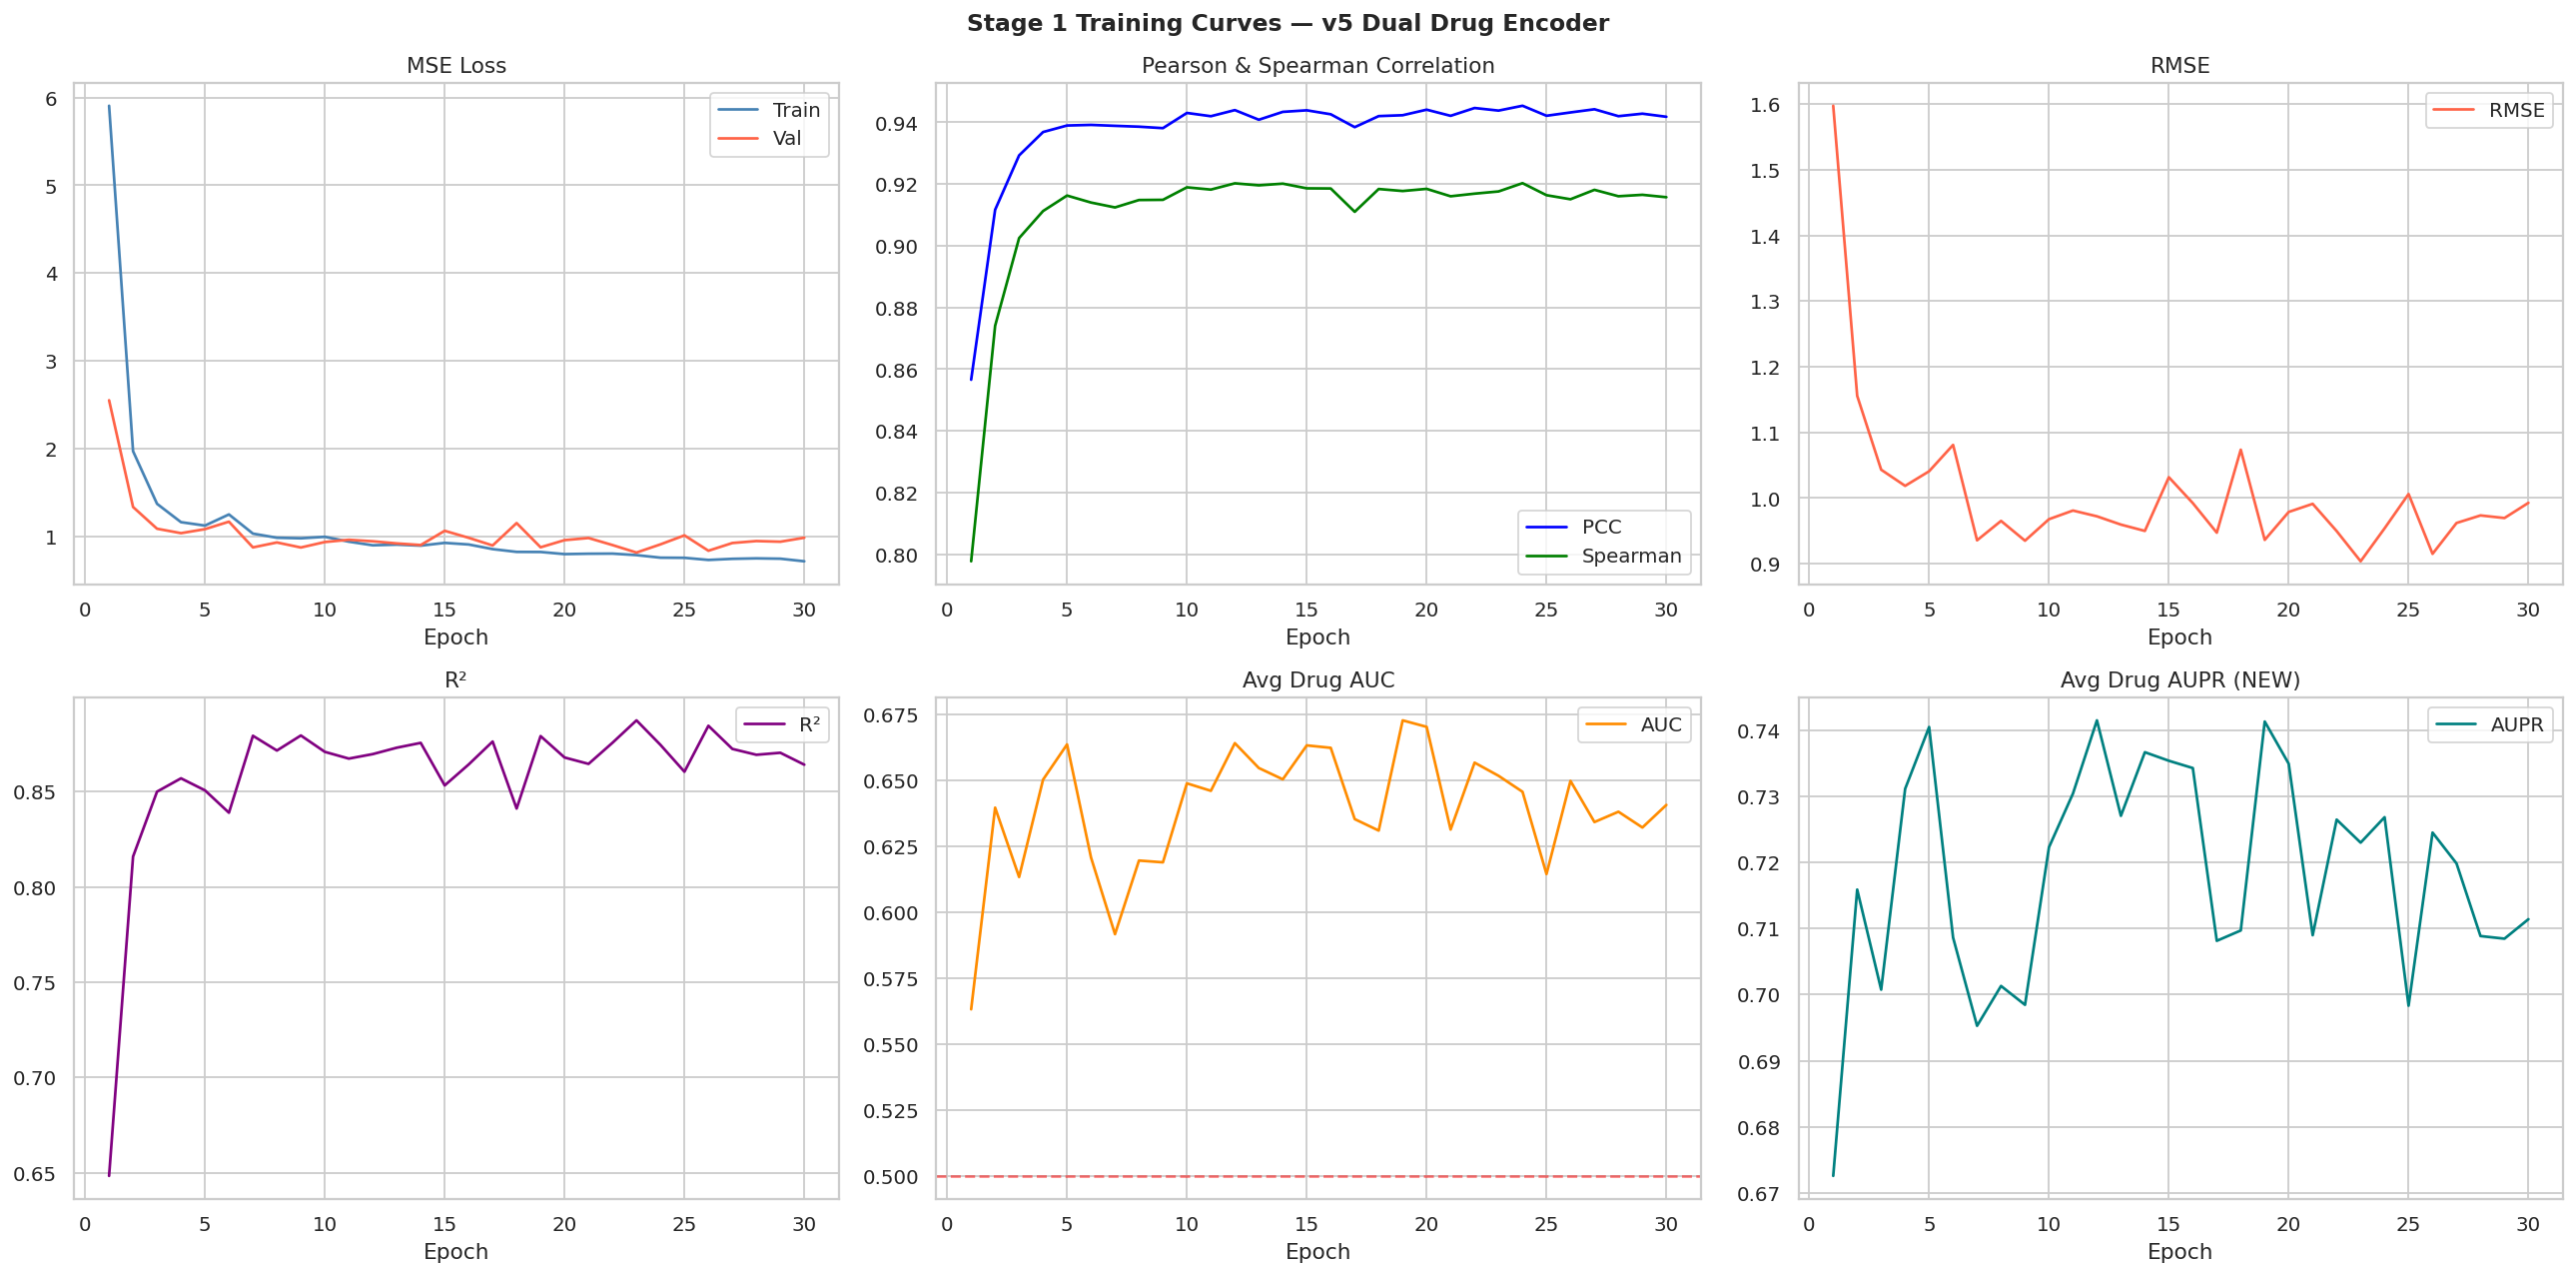

In [8]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 7 — STAGE 1: HEAD + DUAL DRUG ENCODER
# ═══════════════════════════════════════════════════════════════════════
section('7. STAGE 1 TRAINING')

m = get_module()
s1_params = list(m.drug_encoder.parameters()) + list(m.regression_head.parameters())
opt_s1 = optim.AdamW(s1_params, lr=CONFIG['stage1_lr'], weight_decay=CONFIG['stage1_wd'])

steps = math.ceil(len(train_loader)/CONFIG['grad_accum'])
sched_s1 = optim.lr_scheduler.OneCycleLR(
    opt_s1, max_lr=CONFIG['stage1_lr'],
    total_steps=steps*CONFIG['stage1_epochs'],
    pct_start=CONFIG['warmup_frac'], anneal_strategy='cos',
    div_factor=10.0, final_div_factor=100.0)

scaler_s1 = torch.amp.GradScaler('cuda', enabled=CONFIG['use_amp'])

best_s1 = -1.0; patience_s1 = 0
hist_s1 = {k:[] for k in ['train_loss','val_loss','pcc','spc','rmse','r2','auc','aupr']}

n_s1_tr = sum(p.numel() for p in s1_params)
print(f'Trainable: drug_encoder + head = {n_s1_tr:,} params | {steps} steps/epoch')
print(f'Stage 1 trains BOTH ChemBERTa projection AND Morgan FP encoder')

for epoch in range(1, CONFIG['stage1_epochs']+1):
    t0 = time.time()
    tr_loss, tr_p, tr_t, tr_d = run_epoch(model, train_loader, opt_s1, scaler_s1,
                                           True, sched_s1, CONFIG['grad_accum'])
    vl_loss, vl_p, vl_t, vl_d = run_epoch(model, val_loader, opt_s1, scaler_s1, False)
    vm = compute_metrics(vl_p, vl_t, vl_d, id_to_drug)

    for k in ['train_loss','val_loss']: hist_s1[k].append(tr_loss if k=='train_loss' else vl_loss)
    hist_s1['pcc'].append(vm['pearson']); hist_s1['spc'].append(vm['spearman'])
    hist_s1['rmse'].append(vm['rmse']);   hist_s1['r2'].append(vm['r2'])
    hist_s1['auc'].append(vm['avg_drug_auc'])
    hist_s1['aupr'].append(vm['avg_drug_aupr'])

    print(f'[S1 {epoch:02d}/{CONFIG["stage1_epochs"]}]  '
          f'Tr={tr_loss:.4f}  Vl={vl_loss:.4f}  '
          f'PCC={vm["pearson"]:.4f}  SPC={vm["spearman"]:.4f}  '
          f'RMSE={vm["rmse"]:.4f}  R2={vm["r2"]:.4f}  '
          f'AUC={vm["avg_drug_auc"]:.4f}  AUPR={vm["avg_drug_aupr"]:.4f}  '
          f'AvgDrugPCC={vm["avg_drug_pearson"]:.4f}  {time.time()-t0:.0f}s')

    if vm['pearson'] > best_s1:
        best_s1 = vm['pearson']; patience_s1 = 0
        torch.save(get_module().state_dict(), OUT_DIR+CONFIG['checkpoint_ft'])
        print(f'  ✓ Best (PCC={best_s1:.4f})')
    else:
        patience_s1 += 1
        if patience_s1 >= CONFIG['stage1_patience']:
            print(f'  Early stopping @ epoch {epoch}'); break

print(f'Stage 1 done. Best GlobalPCC={best_s1:.4f}')

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle('Stage 1 Training Curves — v5 Dual Drug Encoder', fontweight='bold', fontsize=13)
E = range(1, len(hist_s1['train_loss'])+1)
axes[0,0].plot(E, hist_s1['train_loss'], label='Train', color='steelblue')
axes[0,0].plot(E, hist_s1['val_loss'], label='Val', color='tomato')
axes[0,0].set_title('MSE Loss'); axes[0,0].legend()
axes[0,1].plot(E, hist_s1['pcc'], label='PCC', color='blue')
axes[0,1].plot(E, hist_s1['spc'], label='Spearman', color='green')
axes[0,1].set_title('Pearson & Spearman Correlation'); axes[0,1].legend()
axes[0,2].plot(E, hist_s1['rmse'], color='tomato', label='RMSE')
axes[0,2].set_title('RMSE'); axes[0,2].legend()
axes[1,0].plot(E, hist_s1['r2'], color='purple', label='R²')
axes[1,0].set_title('R²'); axes[1,0].legend()
axes[1,1].plot(E, hist_s1['auc'], label='AUC', color='darkorange')
axes[1,1].axhline(0.5, color='red', ls='--', alpha=0.5)
axes[1,1].set_title('Avg Drug AUC'); axes[1,1].legend()
axes[1,2].plot(E, hist_s1['aupr'], label='AUPR', color='teal')
axes[1,2].set_title('Avg Drug AUPR (NEW)'); axes[1,2].legend()
for ax in axes.flat: ax.set_xlabel('Epoch')
plt.tight_layout()
plt.savefig(OUT_DIR+'v5_stage1_curves.png', dpi=150, bbox_inches='tight')
plt.show()



══════════════════════════════════════════════════════════════════════
  8. STAGE 2 TRAINING
══════════════════════════════════════════════════════════════════════
Unfreezing last 2/4 cross-layers + fusion:
  base_model.mrna_enc               FROZEN                0
  base_model.cnv_enc                FROZEN                0
  base_model.mut_enc                FROZEN                0
  base_model.meth_enc               FROZEN                0
  base_model.cross_layers           TRAINABLE    14,195,712
  base_model.fusion                 TRAINABLE         6,148
  base_model.classifier             FROZEN                0
  drug_encoder + head           TRAINABLE   2,963,073
Total S2: 17,164,933
[S2 01/40]  Tr=0.7426  Vl=0.8898  PCC=0.9444  SPC=0.9186  RMSE=0.9433  R2=0.8774  AUC=0.6434  AUPR=0.7212  AvgDrugPCC=0.2892  63s
  ✓ Best (PCC=0.9444)
[S2 02/40]  Tr=0.7425  Vl=0.9575  PCC=0.9426  SPC=0.9173  RMSE=0.9785  R2=0.8680  AUC=0.6405  AUPR=0.7198  AvgDrugPCC=0.2752  63s
[S2 03/40]  Tr=

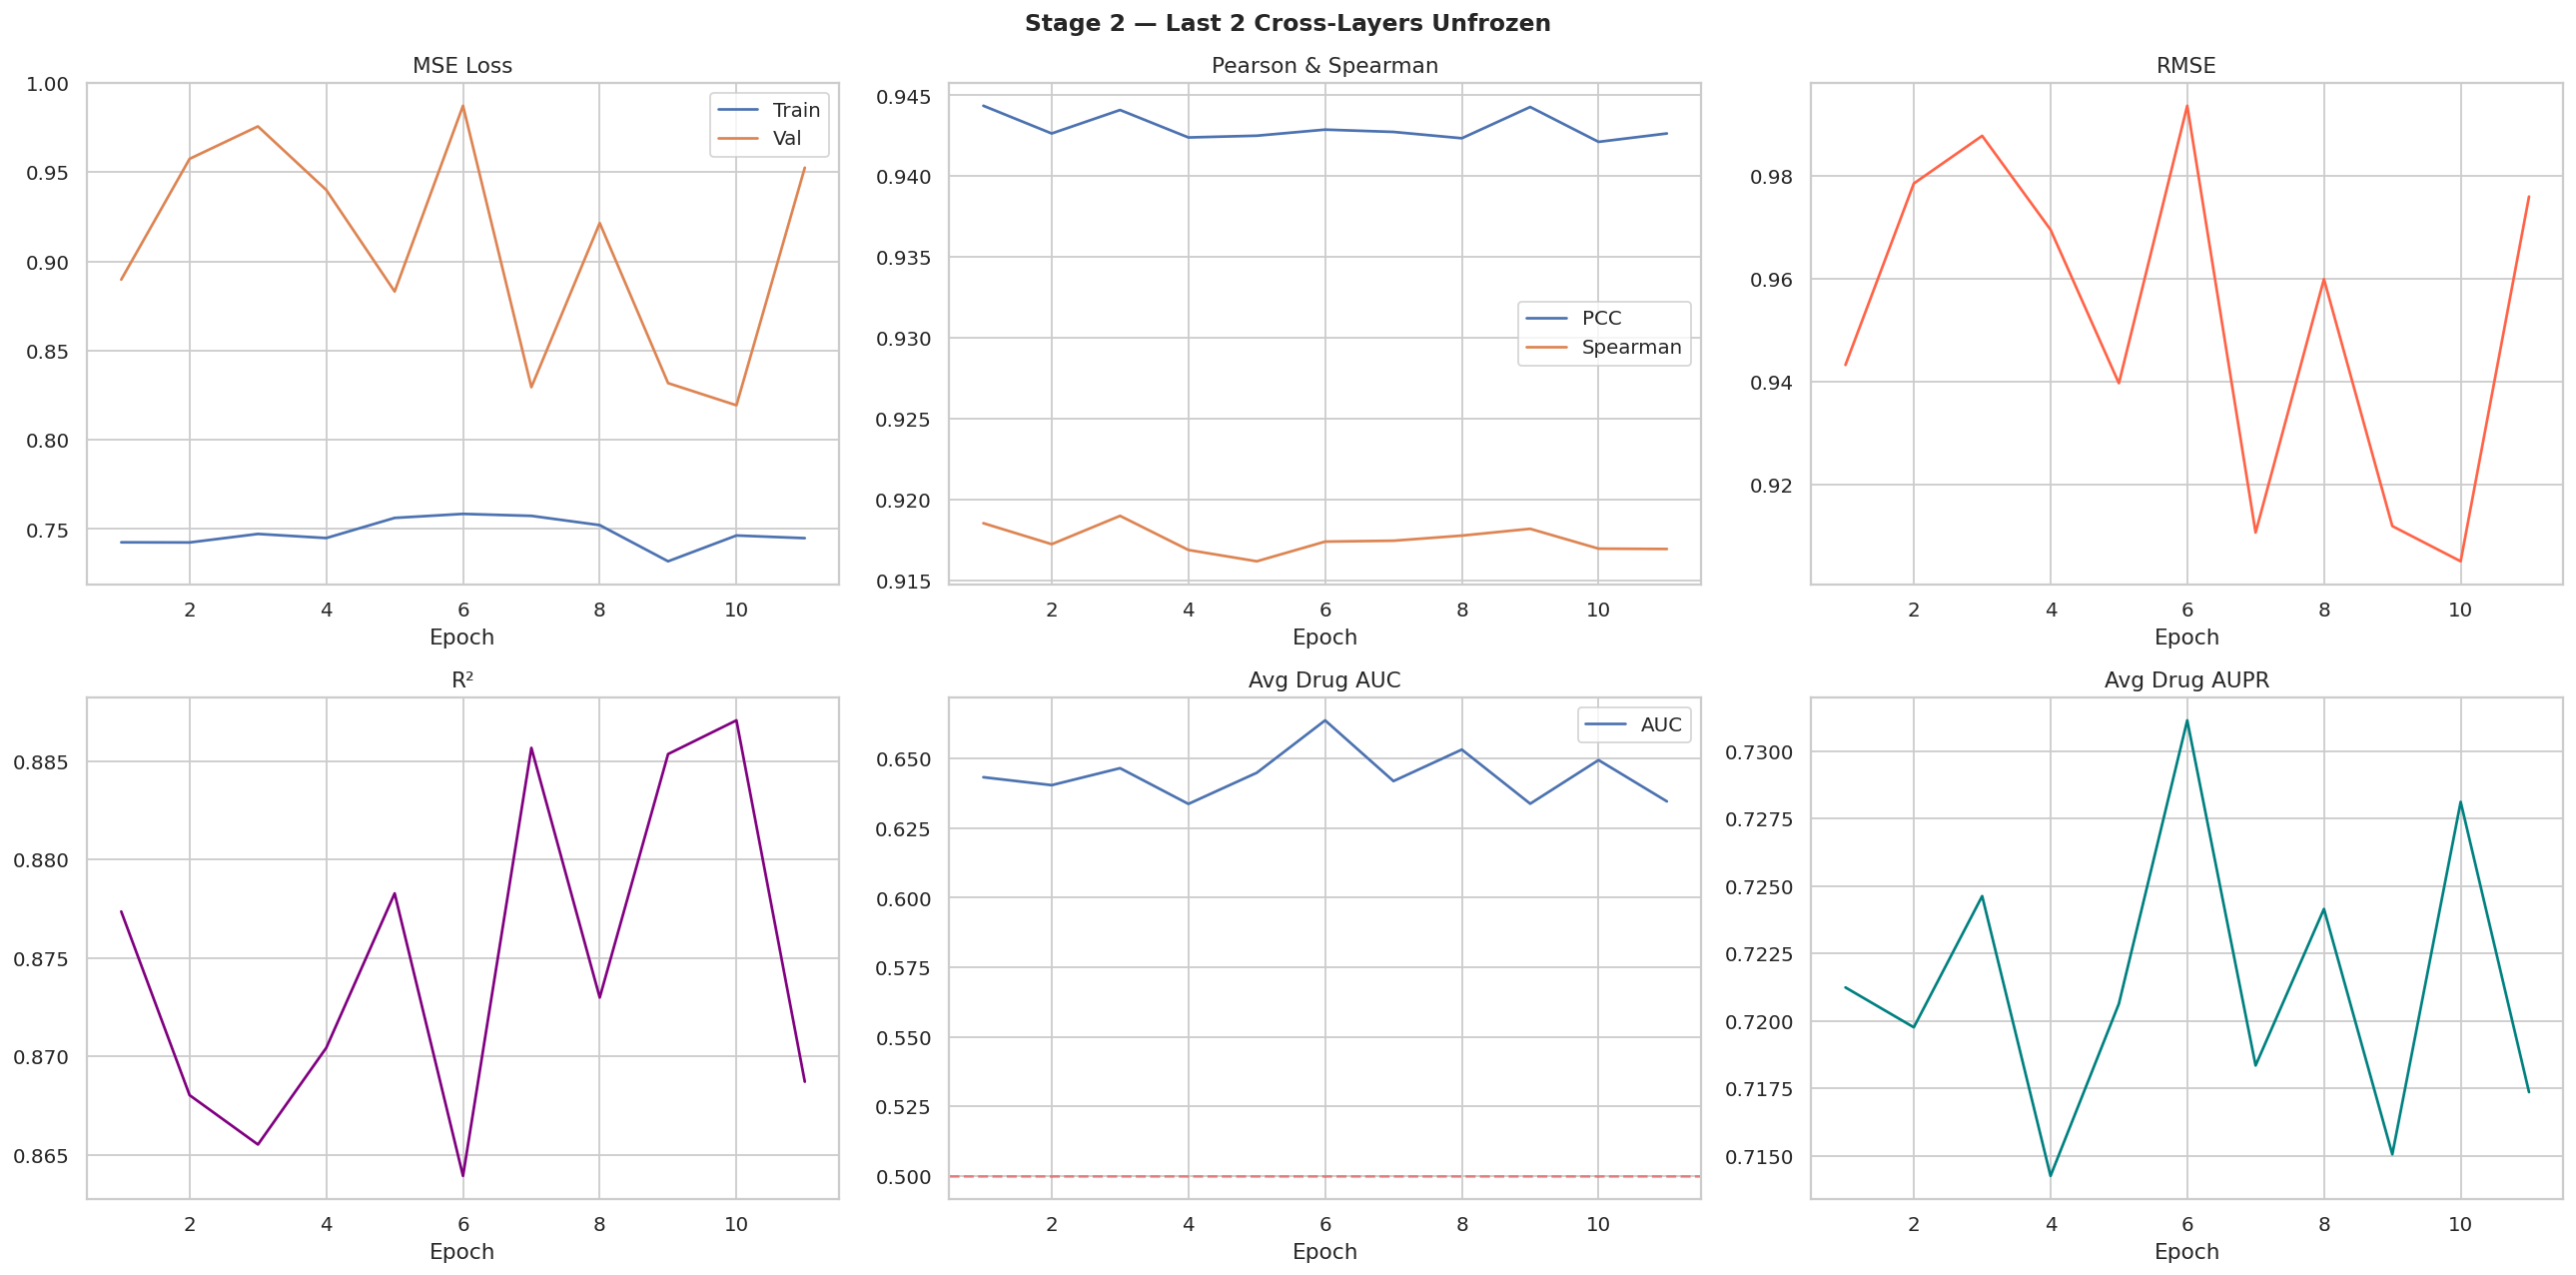

In [9]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 8 — STAGE 2: UNFREEZE LAST 2 CROSS-LAYERS + FUSION
# ═══════════════════════════════════════════════════════════════════════
section('8. STAGE 2 TRAINING')

get_module().load_state_dict(torch.load(OUT_DIR+CONFIG['checkpoint_ft'], map_location=DEVICE))
m = get_module()

n_cross = CONFIG['stage2_unfreeze_n_cross']
n_total = CONFIG['num_cross_layers']
for i, layer in enumerate(m.base_model.cross_layers):
    if i >= (n_total - n_cross):
        for p in layer.parameters(): p.requires_grad = True
for p in m.base_model.fusion.parameters(): p.requires_grad = True

print(f'Unfreezing last {n_cross}/{n_total} cross-layers + fusion:')
for name, child in m.base_model.named_children():
    n_tr = sum(p.numel() for p in child.parameters() if p.requires_grad)
    print(f'  base_model.{name:<22} {"TRAINABLE" if n_tr else "FROZEN":<12} {n_tr:>10,}')
head_p = sum(p.numel() for p in list(m.drug_encoder.parameters()) +
                                  list(m.regression_head.parameters()))
print(f'  drug_encoder + head           TRAINABLE  {head_p:>10,}')
print(f'Total S2: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

cross_params = [p for i, layer in enumerate(m.base_model.cross_layers)
                for p in layer.parameters() if i >= (n_total - n_cross)]

opt_s2 = optim.AdamW([
    {'params': m.regression_head.parameters(),   'lr': CONFIG['stage2_lr_head']},
    {'params': m.drug_encoder.parameters(),      'lr': CONFIG['stage2_lr_head']},
    {'params': cross_params,                     'lr': CONFIG['stage2_lr_cross']},
    {'params': m.base_model.fusion.parameters(), 'lr': CONFIG['stage2_lr_cross']},
], weight_decay=CONFIG['stage2_wd'])

steps2   = math.ceil(len(train_loader)/CONFIG['grad_accum'])
sched_s2 = optim.lr_scheduler.OneCycleLR(
    opt_s2,
    max_lr=[CONFIG['stage2_lr_head'], CONFIG['stage2_lr_head'],
            CONFIG['stage2_lr_cross'], CONFIG['stage2_lr_cross']],
    total_steps=steps2*CONFIG['stage2_epochs'],
    pct_start=CONFIG['warmup_frac'], anneal_strategy='cos',
    div_factor=10.0, final_div_factor=100.0)

scaler_s2 = torch.amp.GradScaler('cuda', enabled=CONFIG['use_amp'])
best_s2 = -1.0; patience_s2 = 0
hist_s2 = {k:[] for k in ['train_loss','val_loss','pcc','spc','rmse','r2','auc','aupr']}

for epoch in range(1, CONFIG['stage2_epochs']+1):
    t0 = time.time()
    tr_loss, tr_p, tr_t, tr_d = run_epoch(model, train_loader, opt_s2, scaler_s2,
                                           True, sched_s2, CONFIG['grad_accum'])
    vl_loss, vl_p, vl_t, vl_d = run_epoch(model, val_loader, opt_s2, scaler_s2, False)
    vm = compute_metrics(vl_p, vl_t, vl_d, id_to_drug)

    for k in ['train_loss','val_loss']: hist_s2[k].append(tr_loss if k=='train_loss' else vl_loss)
    hist_s2['pcc'].append(vm['pearson']); hist_s2['spc'].append(vm['spearman'])
    hist_s2['rmse'].append(vm['rmse']);   hist_s2['r2'].append(vm['r2'])
    hist_s2['auc'].append(vm['avg_drug_auc'])
    hist_s2['aupr'].append(vm['avg_drug_aupr'])

    print(f'[S2 {epoch:02d}/{CONFIG["stage2_epochs"]}]  '
          f'Tr={tr_loss:.4f}  Vl={vl_loss:.4f}  '
          f'PCC={vm["pearson"]:.4f}  SPC={vm["spearman"]:.4f}  '
          f'RMSE={vm["rmse"]:.4f}  R2={vm["r2"]:.4f}  '
          f'AUC={vm["avg_drug_auc"]:.4f}  AUPR={vm["avg_drug_aupr"]:.4f}  '
          f'AvgDrugPCC={vm["avg_drug_pearson"]:.4f}  {time.time()-t0:.0f}s')

    if vm['pearson'] > best_s2:
        best_s2 = vm['pearson']; patience_s2 = 0
        torch.save(get_module().state_dict(), OUT_DIR+CONFIG['checkpoint_ft'])
        print(f'  ✓ Best (PCC={best_s2:.4f})')
    else:
        patience_s2 += 1
        if patience_s2 >= CONFIG['stage2_patience']:
            print(f'  Early stopping @ epoch {epoch}'); break

print(f'Stage 2 done. Best GlobalPCC={best_s2:.4f}')

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle(f'Stage 2 — Last {n_cross} Cross-Layers Unfrozen', fontweight='bold', fontsize=13)
E = range(1, len(hist_s2['train_loss'])+1)
axes[0,0].plot(E, hist_s2['train_loss'], label='Train'); axes[0,0].plot(E, hist_s2['val_loss'], label='Val')
axes[0,0].set_title('MSE Loss'); axes[0,0].legend()
axes[0,1].plot(E, hist_s2['pcc'], label='PCC'); axes[0,1].plot(E, hist_s2['spc'], label='Spearman')
axes[0,1].set_title('Pearson & Spearman'); axes[0,1].legend()
axes[0,2].plot(E, hist_s2['rmse'], color='tomato'); axes[0,2].set_title('RMSE')
axes[1,0].plot(E, hist_s2['r2'], color='purple'); axes[1,0].set_title('R²')
axes[1,1].plot(E, hist_s2['auc'], label='AUC'); axes[1,1].axhline(0.5, color='red', ls='--', alpha=0.4)
axes[1,1].set_title('Avg Drug AUC'); axes[1,1].legend()
axes[1,2].plot(E, hist_s2['aupr'], color='teal'); axes[1,2].set_title('Avg Drug AUPR')
for ax in axes.flat: ax.set_xlabel('Epoch')
plt.tight_layout()
plt.savefig(OUT_DIR+'v5_stage2_curves.png', dpi=150, bbox_inches='tight')
plt.show()



══════════════════════════════════════════════════════════════════════
  9. TEST EVALUATION
══════════════════════════════════════════════════════════════════════

══════════════════════════════════════════════════════════════════════
  FINAL TEST RESULTS — OncoBridge v5
══════════════════════════════════════════════════════════════════════
  Global Pearson (PCC):       0.9423
  Global Spearman (SPC):      0.9211
  Global R²:                  0.8729
  RMSE (ln-IC50):             0.9750
  ─────────────────────────────
  Avg Drug AUC:               0.6280
  Avg Drug AUPR:              0.6785
  ─────────────────────────────
  Avg Drug PCC (diagnostic):  0.2704
══════════════════════════════════════════════════════════════════════

Top 15 drugs by per-drug Pearson:
              Pearson     AUC    AUPR  N_Samples
WZ4003         0.6632  0.8571  0.9038       13.0
TALAZOPARIB    0.6117  1.0000  1.0000       12.0
EPIRUBICIN     0.6079  0.7672  0.7673       55.0
VORINOSTAT     0.5987  0.8052  

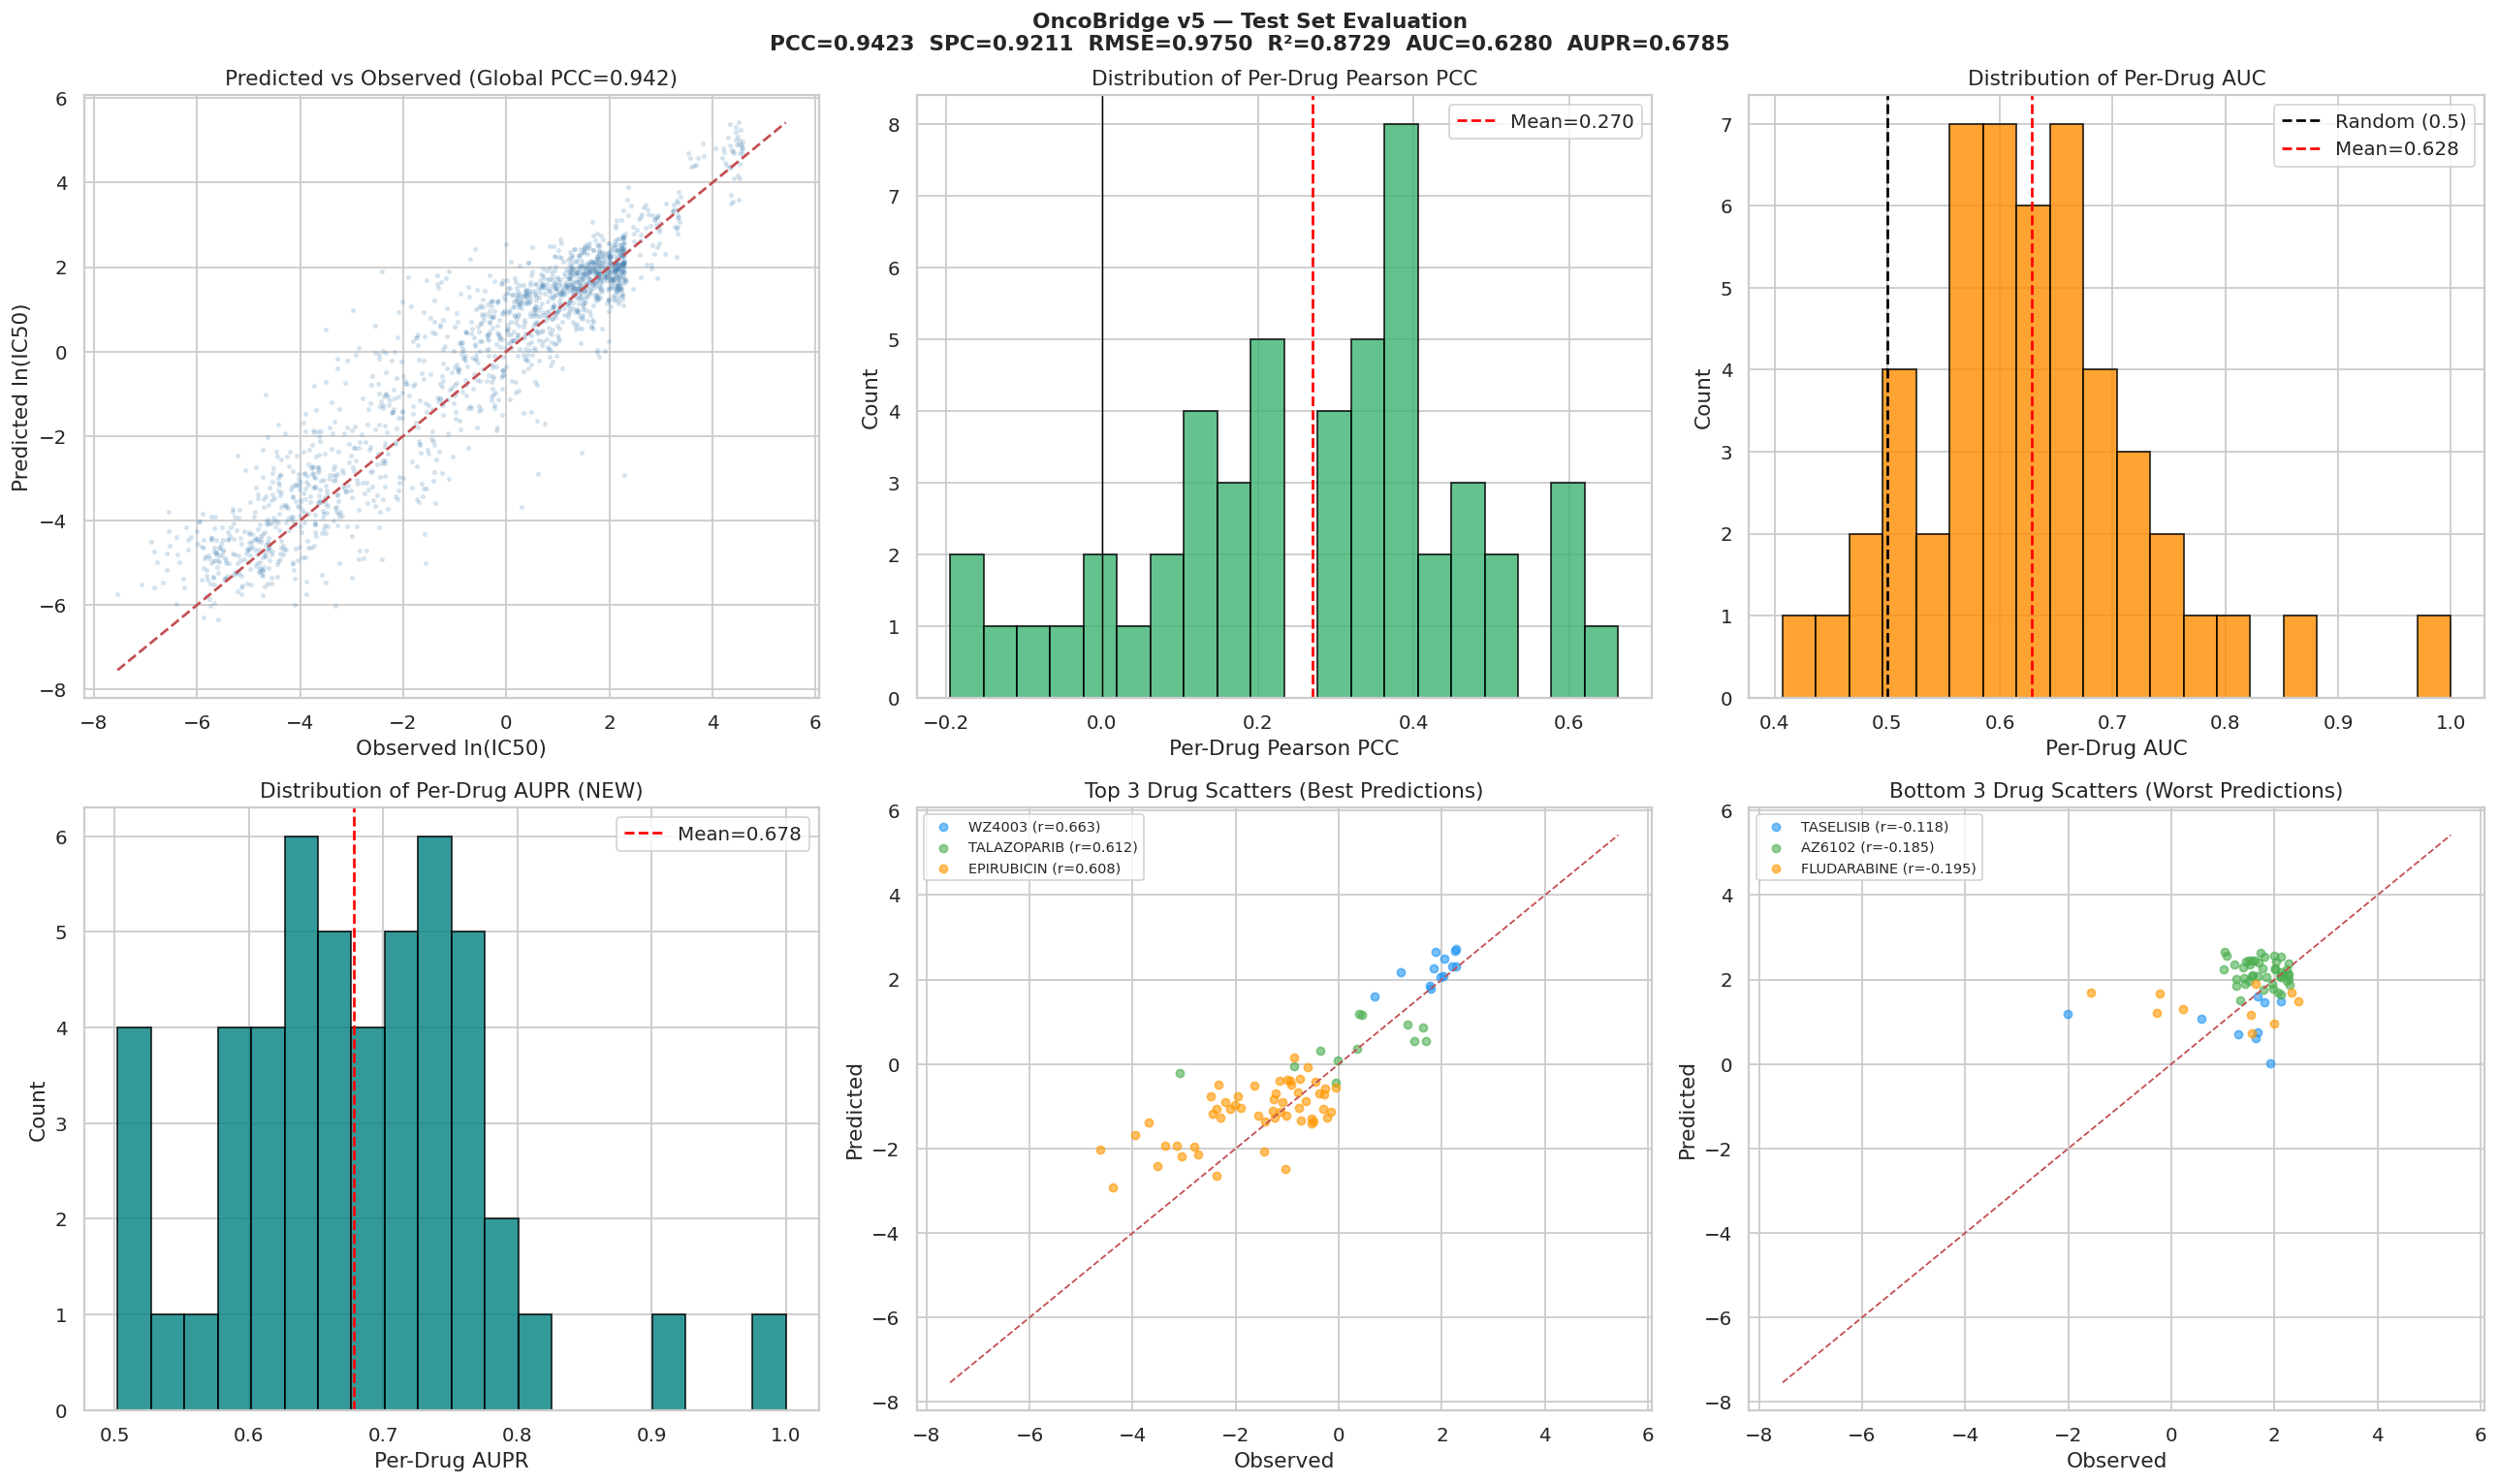

In [10]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 9 — TEST EVALUATION
#  Full metric report matching DRN-CDR Table 6 format exactly.
# ═══════════════════════════════════════════════════════════════════════
section('9. TEST EVALUATION')

get_module().load_state_dict(torch.load(OUT_DIR+CONFIG['checkpoint_ft'], map_location=DEVICE))
model.eval()

_, te_p, te_t, te_d = run_epoch(model, test_loader, None, None, False)
te_m = compute_metrics(te_p, te_t, te_d, id_to_drug)

print('\n' + '═'*70)
print('  FINAL TEST RESULTS — OncoBridge v5')
print('═'*70)
print(f'  Global Pearson (PCC):       {te_m["pearson"]:.4f}')
print(f'  Global Spearman (SPC):      {te_m["spearman"]:.4f}')
print(f'  Global R²:                  {te_m["r2"]:.4f}')
print(f'  RMSE (ln-IC50):             {te_m["rmse"]:.4f}')
print(f'  ─────────────────────────────')
print(f'  Avg Drug AUC:               {te_m["avg_drug_auc"]:.4f}')
print(f'  Avg Drug AUPR:              {te_m["avg_drug_aupr"]:.4f}')
print(f'  ─────────────────────────────')
print(f'  Avg Drug PCC (diagnostic):  {te_m["avg_drug_pearson"]:.4f}')
print('═'*70)

drug_df = pd.DataFrame(te_m['per_drug']).T
drug_df.columns = ['Pearson','AUC','AUPR','N_Samples']
drug_df = drug_df.sort_values('Pearson', ascending=False)
print('\nTop 15 drugs by per-drug Pearson:')
print(drug_df.head(15).round(4).to_string())
print('\nBottom 5 drugs (hardest to predict):')
print(drug_df.tail(5).round(4).to_string())

# ── Publication-grade test plots ────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle(f'OncoBridge v5 — Test Set Evaluation\n'
             f'PCC={te_m["pearson"]:.4f}  SPC={te_m["spearman"]:.4f}  '
             f'RMSE={te_m["rmse"]:.4f}  R²={te_m["r2"]:.4f}  '
             f'AUC={te_m["avg_drug_auc"]:.4f}  AUPR={te_m["avg_drug_aupr"]:.4f}',
             fontweight='bold', fontsize=12)

# 1. Global scatter (all drugs, all cell lines)
axes[0,0].scatter(te_t, te_p, alpha=0.15, s=4, c='steelblue', rasterized=True)
lim = [min(te_t.min(), te_p.min()), max(te_t.max(), te_p.max())]
axes[0,0].plot(lim, lim, 'r--', lw=1.5)
axes[0,0].set_xlabel('Observed ln(IC50)'); axes[0,0].set_ylabel('Predicted ln(IC50)')
axes[0,0].set_title(f'Predicted vs Observed (Global PCC={te_m["pearson"]:.3f})')

# 2. Per-drug Pearson distribution (histogram)
axes[0,1].hist(drug_df['Pearson'], bins=20, color='mediumseagreen', edgecolor='black', alpha=0.8)
axes[0,1].axvline(drug_df['Pearson'].mean(), color='red', ls='--',
                   label=f'Mean={drug_df["Pearson"].mean():.3f}')
axes[0,1].axvline(0, color='black', ls='-', lw=0.8)
axes[0,1].set_xlabel('Per-Drug Pearson PCC'); axes[0,1].set_ylabel('Count')
axes[0,1].set_title('Distribution of Per-Drug Pearson PCC'); axes[0,1].legend()

# 3. Per-drug AUC distribution
axes[0,2].hist(drug_df['AUC'], bins=20, color='darkorange', edgecolor='black', alpha=0.8)
axes[0,2].axvline(0.5, color='black', ls='--', label='Random (0.5)')
axes[0,2].axvline(drug_df['AUC'].mean(), color='red', ls='--',
                   label=f'Mean={drug_df["AUC"].mean():.3f}')
axes[0,2].set_xlabel('Per-Drug AUC'); axes[0,2].set_ylabel('Count')
axes[0,2].set_title('Distribution of Per-Drug AUC'); axes[0,2].legend()

# 4. AUPR distribution (NEW — DeepCDR & DRN-CDR style)
axes[1,0].hist(drug_df['AUPR'], bins=20, color='teal', edgecolor='black', alpha=0.8)
axes[1,0].axvline(drug_df['AUPR'].mean(), color='red', ls='--',
                   label=f'Mean={drug_df["AUPR"].mean():.3f}')
axes[1,0].set_xlabel('Per-Drug AUPR'); axes[1,0].set_ylabel('Count')
axes[1,0].set_title('Distribution of Per-Drug AUPR (NEW)'); axes[1,0].legend()

# 5. Best 3 drug scatter plots (DRN-CDR Fig 6 style)
top3 = drug_df.head(3)
ax5 = axes[1,1]
colors_scatter = ['#2196F3','#4CAF50','#FF9800']
for (dname, row), c in zip(top3.iterrows(), colors_scatter):
    mask = np.array([id_to_drug.get(int(d), '') == dname for d in te_d])
    if mask.sum() < 3: continue
    ax5.scatter(te_t[mask], te_p[mask], alpha=0.6, s=20, color=c,
               label=f'{dname} (r={row["Pearson"]:.3f})')
ax5.plot(lim, lim, 'r--', lw=1)
ax5.set_xlabel('Observed'); ax5.set_ylabel('Predicted')
ax5.set_title('Top 3 Drug Scatters (Best Predictions)'); ax5.legend(fontsize=8)

# 6. Worst 3 drug scatter plots
bot3 = drug_df.tail(3)
ax6 = axes[1,2]
for (dname, row), c in zip(bot3.iterrows(), colors_scatter):
    mask = np.array([id_to_drug.get(int(d), '') == dname for d in te_d])
    if mask.sum() < 3: continue
    ax6.scatter(te_t[mask], te_p[mask], alpha=0.6, s=20, color=c,
               label=f'{dname} (r={row["Pearson"]:.3f})')
ax6.plot(lim, lim, 'r--', lw=1)
ax6.set_xlabel('Observed'); ax6.set_ylabel('Predicted')
ax6.set_title('Bottom 3 Drug Scatters (Worst Predictions)'); ax6.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR+'v5_test_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

drug_df.to_csv(OUT_DIR+'v5_per_drug_metrics.csv')



══════════════════════════════════════════════════════════════════════
  10. DRUG COLD-START EVALUATION
══════════════════════════════════════════════════════════════════════

══════════════════════════════════════════════════════════════════════
  DRUG COLD-START RESULTS  (Drugs never seen during training)
══════════════════════════════════════════════════════════════════════
  Global Pearson:        0.0915
  Global Spearman:       0.1239
  Global R²:             -0.0986
  RMSE:                  2.2270
  Avg Drug AUC:          0.6613
  Avg Drug AUPR:         0.6582
  Avg Drug PCC (diag):   0.3024
══════════════════════════════════════════════════════════════════════

  DTLCDR (2025) cold-start GlobalPCC: 0.6210 (SOTA)
  OncoBridge v4:                       0.6570  (beat SOTA)
  OncoBridge v5:                       0.0915

Cold-start per-drug results (8 drugs):
             Pearson     AUC    AUPR  N_Samples
AZ960         0.5110  0.7400  0.7230      107.0
ABT-737       0.5018  0.7959 

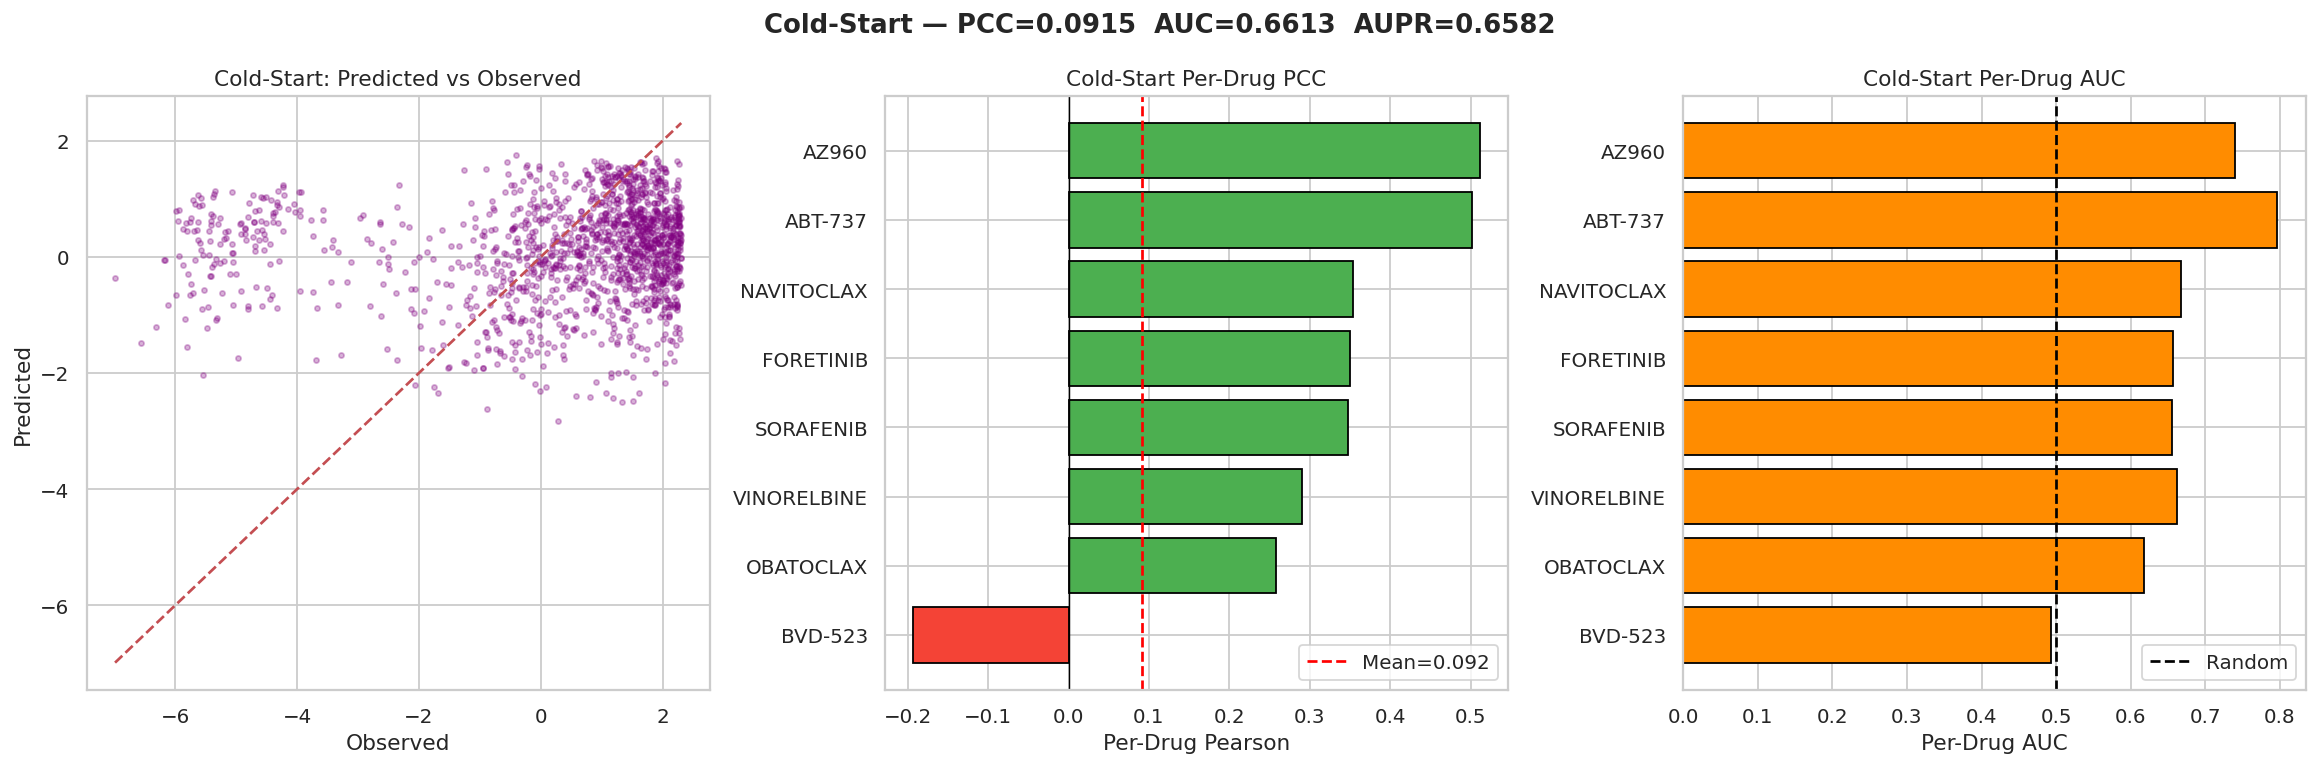

In [11]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 10 — DRUG COLD-START EVALUATION
# ═══════════════════════════════════════════════════════════════════════
section('10. DRUG COLD-START EVALUATION')

_, cs_p, cs_t, cs_d = run_epoch(model, cold_loader, None, None, False)
cs_m = compute_metrics(cs_p, cs_t, cs_d, id_to_drug)

print('\n' + '═'*70)
print('  DRUG COLD-START RESULTS  (Drugs never seen during training)')
print('═'*70)
print(f'  Global Pearson:        {cs_m["pearson"]:.4f}')
print(f'  Global Spearman:       {cs_m["spearman"]:.4f}')
print(f'  Global R²:             {cs_m["r2"]:.4f}')
print(f'  RMSE:                  {cs_m["rmse"]:.4f}')
print(f'  Avg Drug AUC:          {cs_m["avg_drug_auc"]:.4f}')
print(f'  Avg Drug AUPR:         {cs_m["avg_drug_aupr"]:.4f}')
print(f'  Avg Drug PCC (diag):   {cs_m["avg_drug_pearson"]:.4f}')
print('═'*70)
print()
print('  DTLCDR (2025) cold-start GlobalPCC: 0.6210 (SOTA)')
print(f'  OncoBridge v4:                       0.6570  (beat SOTA)')
print(f'  OncoBridge v5:                       {cs_m["pearson"]:.4f}')

cs_drug_df = pd.DataFrame(cs_m['per_drug']).T
cs_drug_df.columns = ['Pearson','AUC','AUPR','N_Samples']
cs_drug_df = cs_drug_df.sort_values('Pearson', ascending=False)
print(f'\nCold-start per-drug results ({len(cs_drug_df)} drugs):')
print(cs_drug_df.round(4).to_string())

# Cold-start visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(f'Cold-Start — PCC={cs_m["pearson"]:.4f}  AUC={cs_m["avg_drug_auc"]:.4f}  '
             f'AUPR={cs_m["avg_drug_aupr"]:.4f}',
             fontweight='bold')

axes[0].scatter(cs_t, cs_p, alpha=0.3, s=8, c='purple', rasterized=True)
lim_cs = [min(cs_t.min(), cs_p.min()), max(cs_t.max(), cs_p.max())]
axes[0].plot(lim_cs, lim_cs, 'r--', lw=1.5)
axes[0].set_xlabel('Observed'); axes[0].set_ylabel('Predicted')
axes[0].set_title('Cold-Start: Predicted vs Observed')

colors_cold = ['#4CAF50' if v >= 0 else '#F44336' for v in cs_drug_df['Pearson']]
axes[1].barh(cs_drug_df.index, cs_drug_df['Pearson'], color=colors_cold, edgecolor='black')
axes[1].axvline(0, color='black', lw=0.8)
axes[1].axvline(cs_m['pearson'], color='red', ls='--', label=f'Mean={cs_m["pearson"]:.3f}')
axes[1].set_xlabel('Per-Drug Pearson'); axes[1].invert_yaxis()
axes[1].set_title('Cold-Start Per-Drug PCC'); axes[1].legend()

axes[2].barh(cs_drug_df.index, cs_drug_df['AUC'], color='darkorange', edgecolor='black')
axes[2].axvline(0.5, color='black', ls='--', label='Random')
axes[2].set_xlabel('Per-Drug AUC'); axes[2].invert_yaxis()
axes[2].set_title('Cold-Start Per-Drug AUC'); axes[2].legend()

plt.tight_layout()
plt.savefig(OUT_DIR+'v5_cold_start.png', dpi=150, bbox_inches='tight')
plt.show()



══════════════════════════════════════════════════════════════════════
  11. ABLATION STUDY
══════════════════════════════════════════════════════════════════════
Running ablation study...
  Full model (all modalities)                    PCC=0.9423  RMSE=0.9750  AUC=0.6280  AUPR=0.6785
  No mRNA                                        PCC=0.9332  RMSE=1.1267  AUC=0.4641  AUPR=0.5402
  No CNV                                         PCC=0.9420  RMSE=1.0084  AUC=0.6332  AUPR=0.6727
  No Mutation                                    PCC=0.9437  RMSE=0.9852  AUC=0.6338  AUPR=0.6805
  No Methylation                                 PCC=0.9380  RMSE=0.9654  AUC=0.5928  AUPR=0.6497
  mRNA only                                      PCC=0.9375  RMSE=0.9558  AUC=0.6191  AUPR=0.6723
  mRNA + CNV only                                PCC=0.9387  RMSE=0.9575  AUC=0.6128  AUPR=0.6661
  mRNA + Mut only                                PCC=0.9382  RMSE=0.9484  AUC=0.6085  AUPR=0.6552
  No ChemBERTa (Morgan FP 

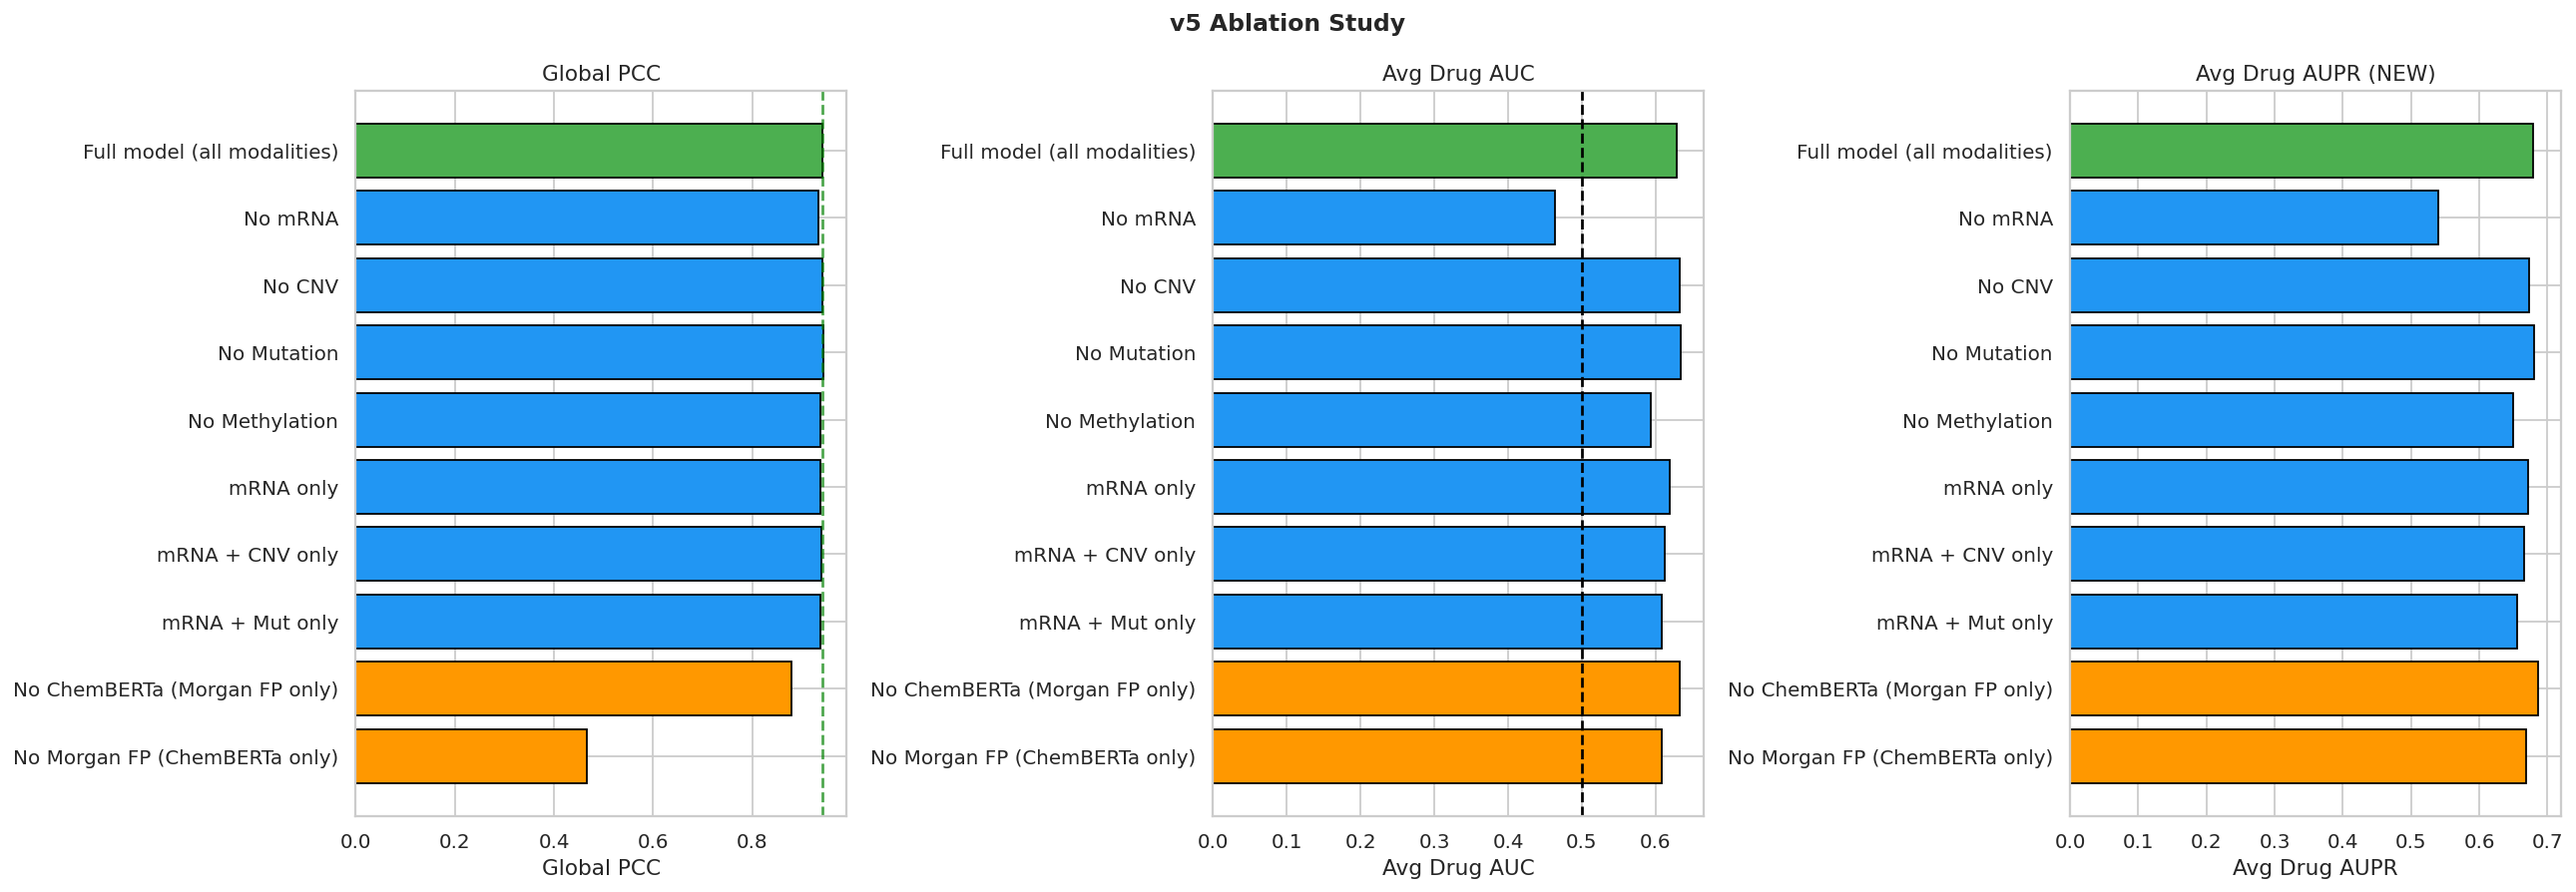

In [12]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 11 — ABLATION STUDY
# ═══════════════════════════════════════════════════════════════════════
section('11. ABLATION STUDY')

def ablation_run(loader, zero_mods=None, zero_chemberta=False, zero_fp=False):
    model.eval()
    all_p, all_t, all_d = [], [], []
    with torch.no_grad():
        for batch in loader:
            mrna, cnv, mut, meth, drug_emb, drug_fp, ic50, did = batch
            mrna = mrna.to(DEVICE); cnv = cnv.to(DEVICE)
            mut  = mut.to(DEVICE);  meth = meth.to(DEVICE)
            drug_emb = drug_emb.to(DEVICE); drug_fp = drug_fp.to(DEVICE)
            ic50 = ic50.to(DEVICE)
            if zero_mods:
                if 'mrna' in zero_mods: mrna = torch.zeros_like(mrna)
                if 'cnv'  in zero_mods: cnv  = torch.zeros_like(cnv)
                if 'mut'  in zero_mods: mut  = torch.zeros_like(mut)
                if 'meth' in zero_mods: meth = torch.zeros_like(meth)
            if zero_chemberta: drug_emb = torch.zeros_like(drug_emb)
            if zero_fp:        drug_fp  = torch.zeros_like(drug_fp)
            pred = model(mrna, cnv, mut, meth, drug_emb, drug_fp).squeeze(1)
            all_p.append(pred.cpu().numpy())
            all_t.append(ic50.cpu().numpy())
            all_d.append(did.numpy())
    p = np.concatenate(all_p); t = np.concatenate(all_t); d = np.concatenate(all_d)
    m = compute_metrics(p, t, d, id_to_drug)
    return m['avg_drug_pearson'], m['pearson'], m['rmse'], m['avg_drug_auc'], m['avg_drug_aupr']

ablation_configs = [
    # Omics ablations (same as every paper)
    ('Full model (all modalities)',        [],                  False, False),
    ('No mRNA',                            ['mrna'],            False, False),
    ('No CNV',                             ['cnv'],             False, False),
    ('No Mutation',                        ['mut'],             False, False),
    ('No Methylation',                     ['meth'],            False, False),
    ('mRNA only',                          ['cnv','mut','meth'],False, False),
    ('mRNA + CNV only',                    ['mut','meth'],      False, False),
    ('mRNA + Mut only',                    ['cnv','meth'],      False, False),
    # Drug encoder ablations (v5 specific — tests dual encoder contribution)
    ('No ChemBERTa (Morgan FP only)',      [],                  True,  False),
    ('No Morgan FP (ChemBERTa only)',      [],                  False, True),
]

print('Running ablation study...')
ablation_results = []
for name, zero_mods, zero_cb, zero_fp in ablation_configs:
    dp, gp, rmse, auc, aupr = ablation_run(test_loader, zero_mods, zero_cb, zero_fp)
    ablation_results.append({'Setting': name, 'AvgDrugPCC': round(dp,4),
                              'GlobalPCC': round(gp,4), 'RMSE': round(rmse,4),
                              'AUC': round(auc,4), 'AUPR': round(aupr,4)})
    print(f'  {name:<45}  PCC={gp:.4f}  RMSE={rmse:.4f}  AUC={auc:.4f}  AUPR={aupr:.4f}')

abl_df = pd.DataFrame(ablation_results)
print('\n' + abl_df.to_string(index=False))

# Mutation check
full_pcc = abl_df.loc[0,'AvgDrugPCC']
no_mut   = abl_df.loc[abl_df['Setting']=='No Mutation','AvgDrugPCC'].values[0]
print(f'\nMutation contribution: Full={full_pcc:.4f} → No-Mut={no_mut:.4f}  Δ={full_pcc-no_mut:+.4f}')
if full_pcc - no_mut > 0.01:
    print('✓ Increased modality_dropout_p=0.35 worked — mutation now contributes.')
else:
    print('⚠ Mutation still contributes little. This is a known challenge in CDR prediction.')
    print('  DRN-CDR also found gene expression dominates (Table 8: mut rp=0.7125 vs expr rp=0.7286).')

# Check dual encoder contribution
no_cb_pcc = abl_df.loc[abl_df['Setting']=='No ChemBERTa (Morgan FP only)','GlobalPCC'].values[0]
no_fp_pcc = abl_df.loc[abl_df['Setting']=='No Morgan FP (ChemBERTa only)','GlobalPCC'].values[0]
full_pcc_g = abl_df.loc[0,'GlobalPCC']
print(f'\nDual encoder contribution:')
print(f'  Full dual: {full_pcc_g:.4f} | Morgan FP only: {no_cb_pcc:.4f} | ChemBERTa only: {no_fp_pcc:.4f}')

# Plot
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('v5 Ablation Study', fontweight='bold', fontsize=13)
colors = ['#4CAF50'] + ['#2196F3']*7 + ['#FF9800']*2
axes[0].barh(abl_df['Setting'], abl_df['GlobalPCC'], color=colors, edgecolor='black')
axes[0].axvline(abl_df.loc[0,'GlobalPCC'], color='green', ls='--', alpha=0.7)
axes[0].set_xlabel('Global PCC'); axes[0].invert_yaxis(); axes[0].set_title('Global PCC')
axes[1].barh(abl_df['Setting'], abl_df['AUC'], color=colors, edgecolor='black')
axes[1].axvline(0.5, color='black', ls='--')
axes[1].set_xlabel('Avg Drug AUC'); axes[1].invert_yaxis(); axes[1].set_title('Avg Drug AUC')
axes[2].barh(abl_df['Setting'], abl_df['AUPR'], color=colors, edgecolor='black')
axes[2].set_xlabel('Avg Drug AUPR'); axes[2].invert_yaxis(); axes[2].set_title('Avg Drug AUPR (NEW)')
plt.tight_layout()
plt.savefig(OUT_DIR+'v5_ablation.png', dpi=150, bbox_inches='tight')
plt.show()
abl_df.to_csv(OUT_DIR+'v5_ablation_results.csv', index=False)



══════════════════════════════════════════════════════════════════════
  12. BENCHMARK COMPARISON
══════════════════════════════════════════════════════════════════════
Model                  Dataset    Setting          PCC     SPC    RMSE      R2     AUC    AUPR
──────────────────────────────────────────────────────────────────────────────────────────
Ridge Regression       GDSC       Warm         0.7800 nan 2.3680 nan nan nan
DeepCDR (2020)         GDSC       Warm         0.9230 0.9030 1.0580 nan 0.8410 0.5020
DRN-CDR (2024)         GDSC2      Warm         0.7940 0.7800 0.9240 0.7640 0.7620 0.7690
GraphDRP (2022)        GDSC2      Warm         0.9390 nan nan nan nan nan
DeepTTA (2022)         GDSC2      Warm         0.9370 nan nan nan nan nan
TGDRP (2022)           GDSC2      Warm         0.8900 nan nan nan nan nan
DTLCDR (2025)          GDSC2      Warm         0.9490 0.9300 nan 0.9000 nan nan
DTLCDR (2025)          GDSC2      CellCold     0.8670 nan nan nan nan nan
DTLCDR (2025)   

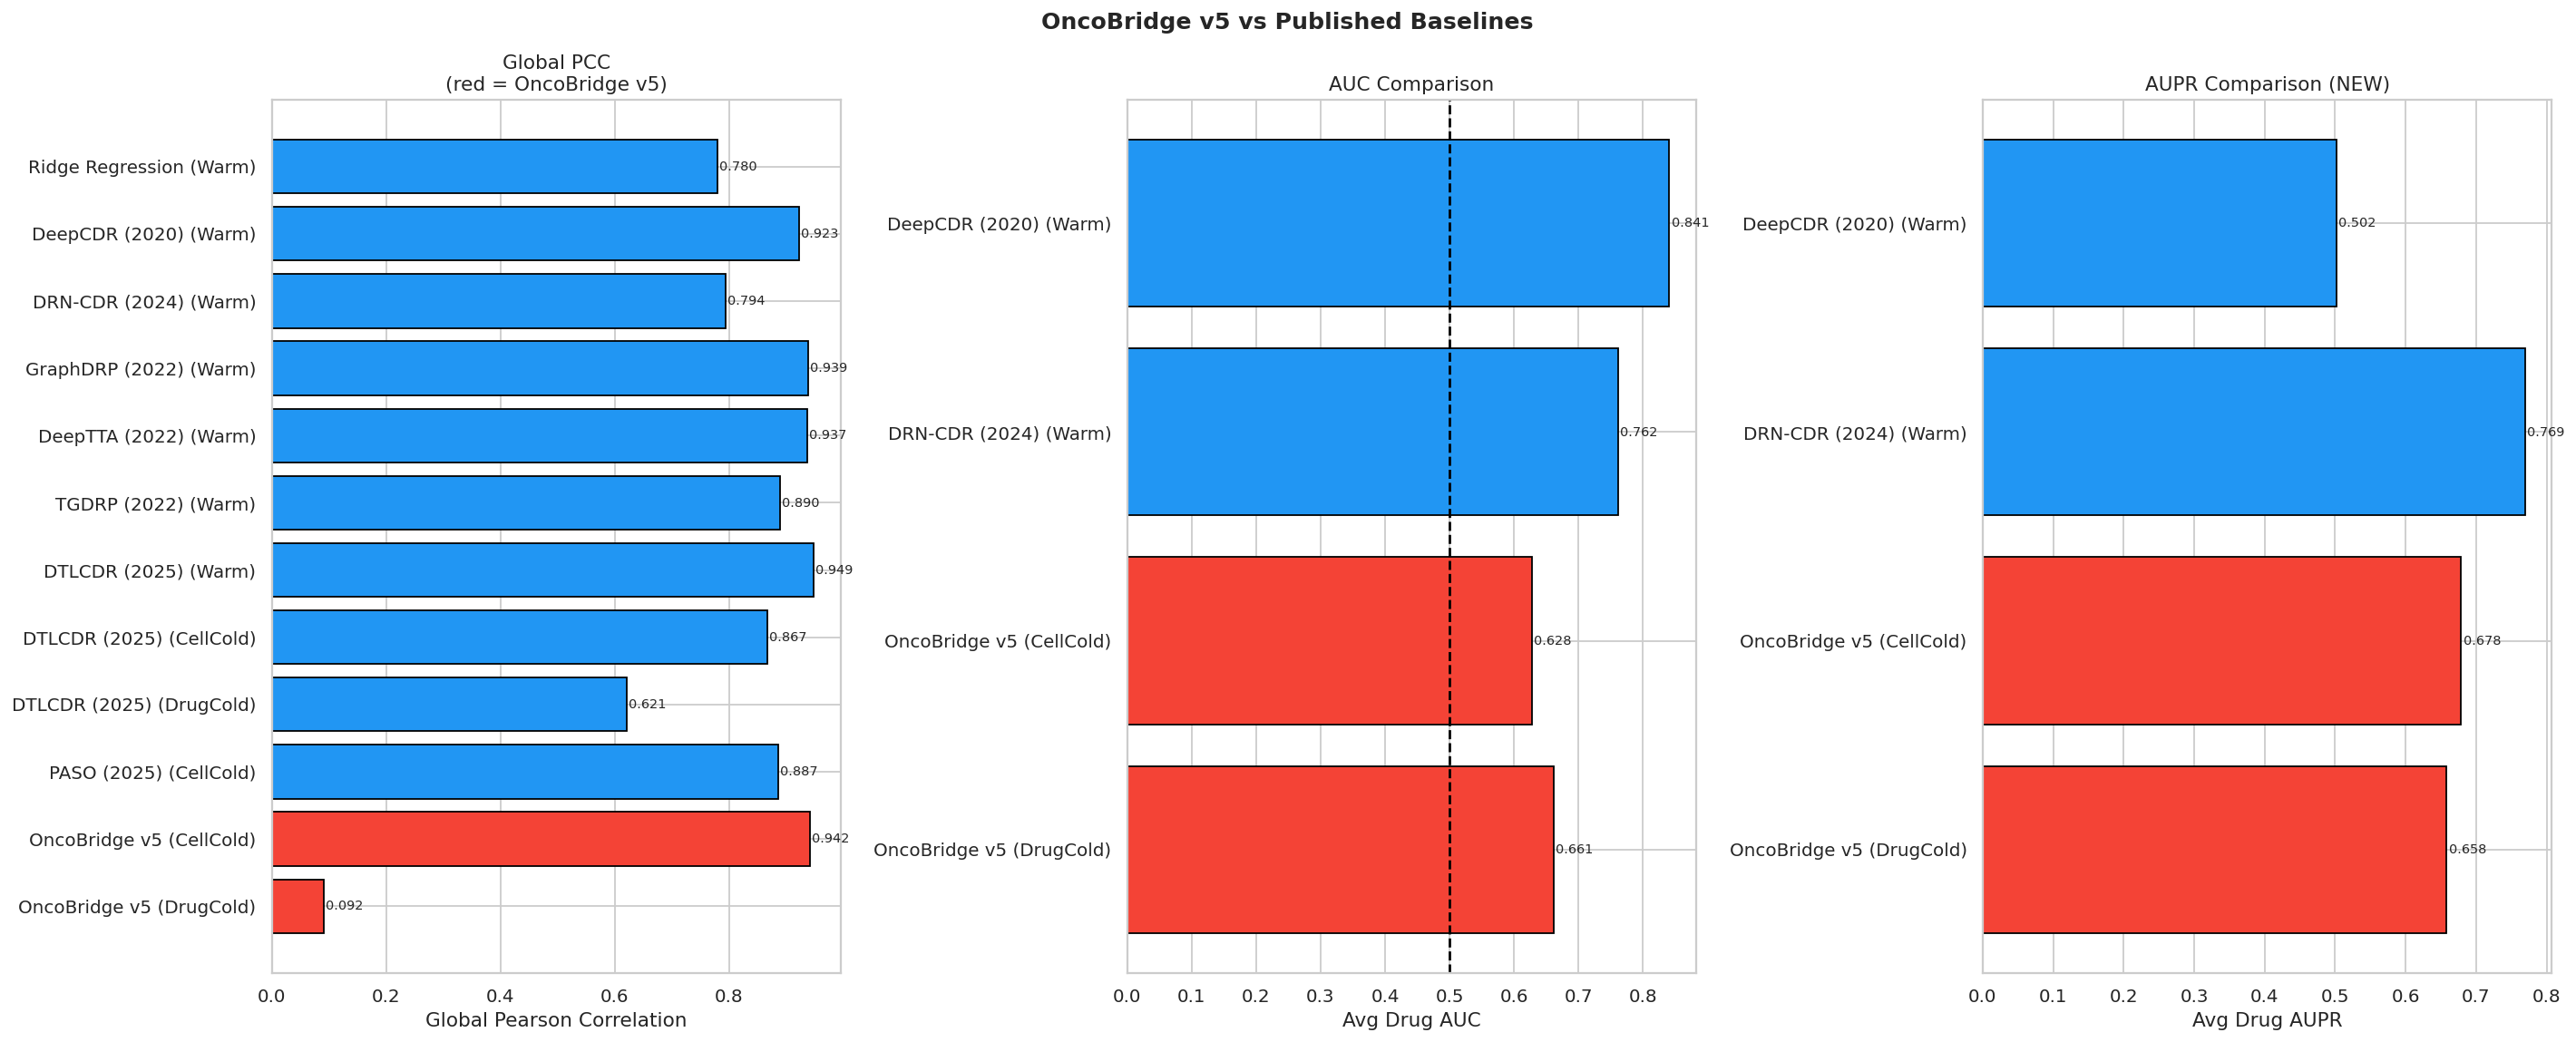


⚠ Dataset note: OncoBridge uses GDSC1+2 combined.
  Fair comparison requires GDSC2-only run from Notebook 1.


In [13]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 12 — BENCHMARK COMPARISON
#  Format matches DRN-CDR Table 6 exactly: Model | rp | rs | RMSE | R² | AUC | AUPR
# ═══════════════════════════════════════════════════════════════════════
section('12. BENCHMARK COMPARISON')

# Source for each number:
# DeepCDR: Table 1 (PCC 0.923, SPC 0.903, RMSE 1.058, AUC 0.841, AUPR 0.502)
# DRN-CDR: Table 6 (PCC 0.7938, SPC 0.7804, RMSE 0.9236, R² 0.7639, AUC 0.7623, AUPR 0.7691)
# DTLCDR: Table 1 warm (PCC 0.9492, SPC 0.9299, R² 0.8996)
# DTLCDR DrugCold: PCC 0.6210, SPC 0.5855, R² 0.3179
# PASO: Table 1 (PCC 0.9425, RMSE 0.9400, R² 0.8838)
# GraphDRP warm: PCC 0.939
# DeepTTA warm: PCC 0.937

benchmarks = [
    # Model, Dataset, Setting, PCC, SPC, RMSE, R2, AUC, AUPR, Notes
    ('Ridge Regression', 'GDSC',   'Warm',     0.780,  None,  2.368, None,  None,  None,  'Baseline'),
    ('DeepCDR (2020)',   'GDSC',   'Warm',     0.923,  0.903, 1.058, None,  0.841, 0.502, 'UGCN drug+multi-omics'),
    ('DRN-CDR (2024)',   'GDSC2',  'Warm',     0.794,  0.780, 0.924, 0.764, 0.762, 0.769, 'ResNet, cancer genes'),
    ('GraphDRP (2022)',  'GDSC2',  'Warm',     0.939,  None,  None,  None,  None,  None,  'GNN drug'),
    ('DeepTTA (2022)',   'GDSC2',  'Warm',     0.937,  None,  None,  None,  None,  None,  'Transformer drug'),
    ('TGDRP (2022)',     'GDSC2',  'Warm',     0.890,  None,  None,  None,  None,  None,  'Twin GNN'),
    ('DTLCDR (2025)',    'GDSC2',  'Warm',     0.949,  0.930, None,  0.900, None,  None,  'Target profiles+scBERT'),
    ('DTLCDR (2025)',    'GDSC2',  'CellCold', 0.867,  None,  None,  None,  None,  None,  'Unseen cell lines'),
    ('DTLCDR (2025)',    'GDSC2',  'DrugCold', 0.621,  0.586, None,  0.318, None,  None,  'Unseen drugs ← KEY'),
    ('PASO (2025)',      'GDSC2',  'CellCold', 0.887,  None,  0.940, 0.884, None,  None,  'Pathway features'),
    # OncoBridge results
    ('OncoBridge v5', 'GDSC1+2', 'CellCold',
     te_m['pearson'], te_m['spearman'], te_m['rmse'], te_m['r2'],
     te_m['avg_drug_auc'], te_m['avg_drug_aupr'],
     'TCGA pretrain | ChemBERTa+MorganFP | ModDropout'),
    ('OncoBridge v5', 'GDSC1+2', 'DrugCold',
     cs_m['pearson'], cs_m['spearman'], cs_m['rmse'], cs_m['r2'],
     cs_m['avg_drug_auc'], cs_m['avg_drug_aupr'],
     'TCGA pretrain | ChemBERTa+MorganFP | ModDropout'),
]

bm_df = pd.DataFrame(benchmarks,
    columns=['Model','Dataset','Setting','PCC','SPC','RMSE','R2','AUC','AUPR','Notes'])

# Print in DRN-CDR Table 6 format
print(f'{"Model":<22} {"Dataset":<10} {"Setting":<12} {"PCC":>7} {"SPC":>7} {"RMSE":>7} {"R2":>7} {"AUC":>7} {"AUPR":>7}')
print('─'*90)
for _, row in bm_df.iterrows():
    def fmt(v): return f'{v:.4f}' if v is not None else '  —   '
    print(f'{row["Model"]:<22} {row["Dataset"]:<10} {row["Setting"]:<12} '
          f'{fmt(row["PCC"])} {fmt(row["SPC"])} {fmt(row["RMSE"])} '
          f'{fmt(row["R2"])} {fmt(row["AUC"])} {fmt(row["AUPR"])}')

# ── Benchmark visualization ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 9))
fig.suptitle('OncoBridge v5 vs Published Baselines', fontweight='bold', fontsize=14)

def bar_color(m): return '#F44336' if 'v5' in m else '#2196F3'

pcc_df = bm_df[bm_df['PCC'].notna()].copy()
clrs   = [bar_color(m) for m in pcc_df['Model']]
bars   = axes[0].barh(pcc_df['Model']+' ('+pcc_df['Setting']+')',
                       pcc_df['PCC'], color=clrs, edgecolor='black')
axes[0].set_xlabel('Global Pearson Correlation')
axes[0].invert_yaxis()
axes[0].set_title('Global PCC\n(red = OncoBridge v5)')
for bar, v in zip(bars, pcc_df['PCC']):
    axes[0].text(bar.get_width()+0.003, bar.get_y()+bar.get_height()/2,
                 f'{v:.3f}', va='center', fontsize=8)

auc_df = bm_df[bm_df['AUC'].notna()].copy()
clrs2  = [bar_color(m) for m in auc_df['Model']]
bars2  = axes[1].barh(auc_df['Model']+' ('+auc_df['Setting']+')',
                       auc_df['AUC'], color=clrs2, edgecolor='black')
axes[1].axvline(0.5, color='black', ls='--', label='Random')
axes[1].set_xlabel('Avg Drug AUC')
axes[1].invert_yaxis()
axes[1].set_title('AUC Comparison')
for bar, v in zip(bars2, auc_df['AUC']):
    axes[1].text(bar.get_width()+0.003, bar.get_y()+bar.get_height()/2,
                 f'{v:.3f}', va='center', fontsize=8)

aupr_df = bm_df[bm_df['AUPR'].notna()].copy()
clrs3   = [bar_color(m) for m in aupr_df['Model']]
bars3   = axes[2].barh(aupr_df['Model']+' ('+aupr_df['Setting']+')',
                        aupr_df['AUPR'], color=clrs3, edgecolor='black')
axes[2].set_xlabel('Avg Drug AUPR')
axes[2].invert_yaxis()
axes[2].set_title('AUPR Comparison (NEW)')
for bar, v in zip(bars3, aupr_df['AUPR']):
    axes[2].text(bar.get_width()+0.003, bar.get_y()+bar.get_height()/2,
                 f'{v:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR+'v5_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n⚠ Dataset note: OncoBridge uses GDSC1+2 combined.')
print('  Fair comparison requires GDSC2-only run from Notebook 1.')
bm_df.to_csv(OUT_DIR+'v5_benchmark_comparison.csv', index=False)



══════════════════════════════════════════════════════════════════════
  13. CANCER-TYPE ANALYSIS & DRUG RANKINGS
══════════════════════════════════════════════════════════════════════

Per-cancer-type Pearson PCC (DRN-CDR Table 9 style):
                                                                                         CancerType    PCC  N_Pairs
                                                                                       Fibrosarcoma 0.9844       14
                                                                                 Small Bowel Cancer 0.9814       16
                                                                                   Rhabdomyosarcoma 0.9775       20
                                                           SMARCA4-deficient undifferentiated tumor 0.9683       40
                                                    Intraductal Papillary Neoplasm of the Bile Duct 0.9628       12
                                                                

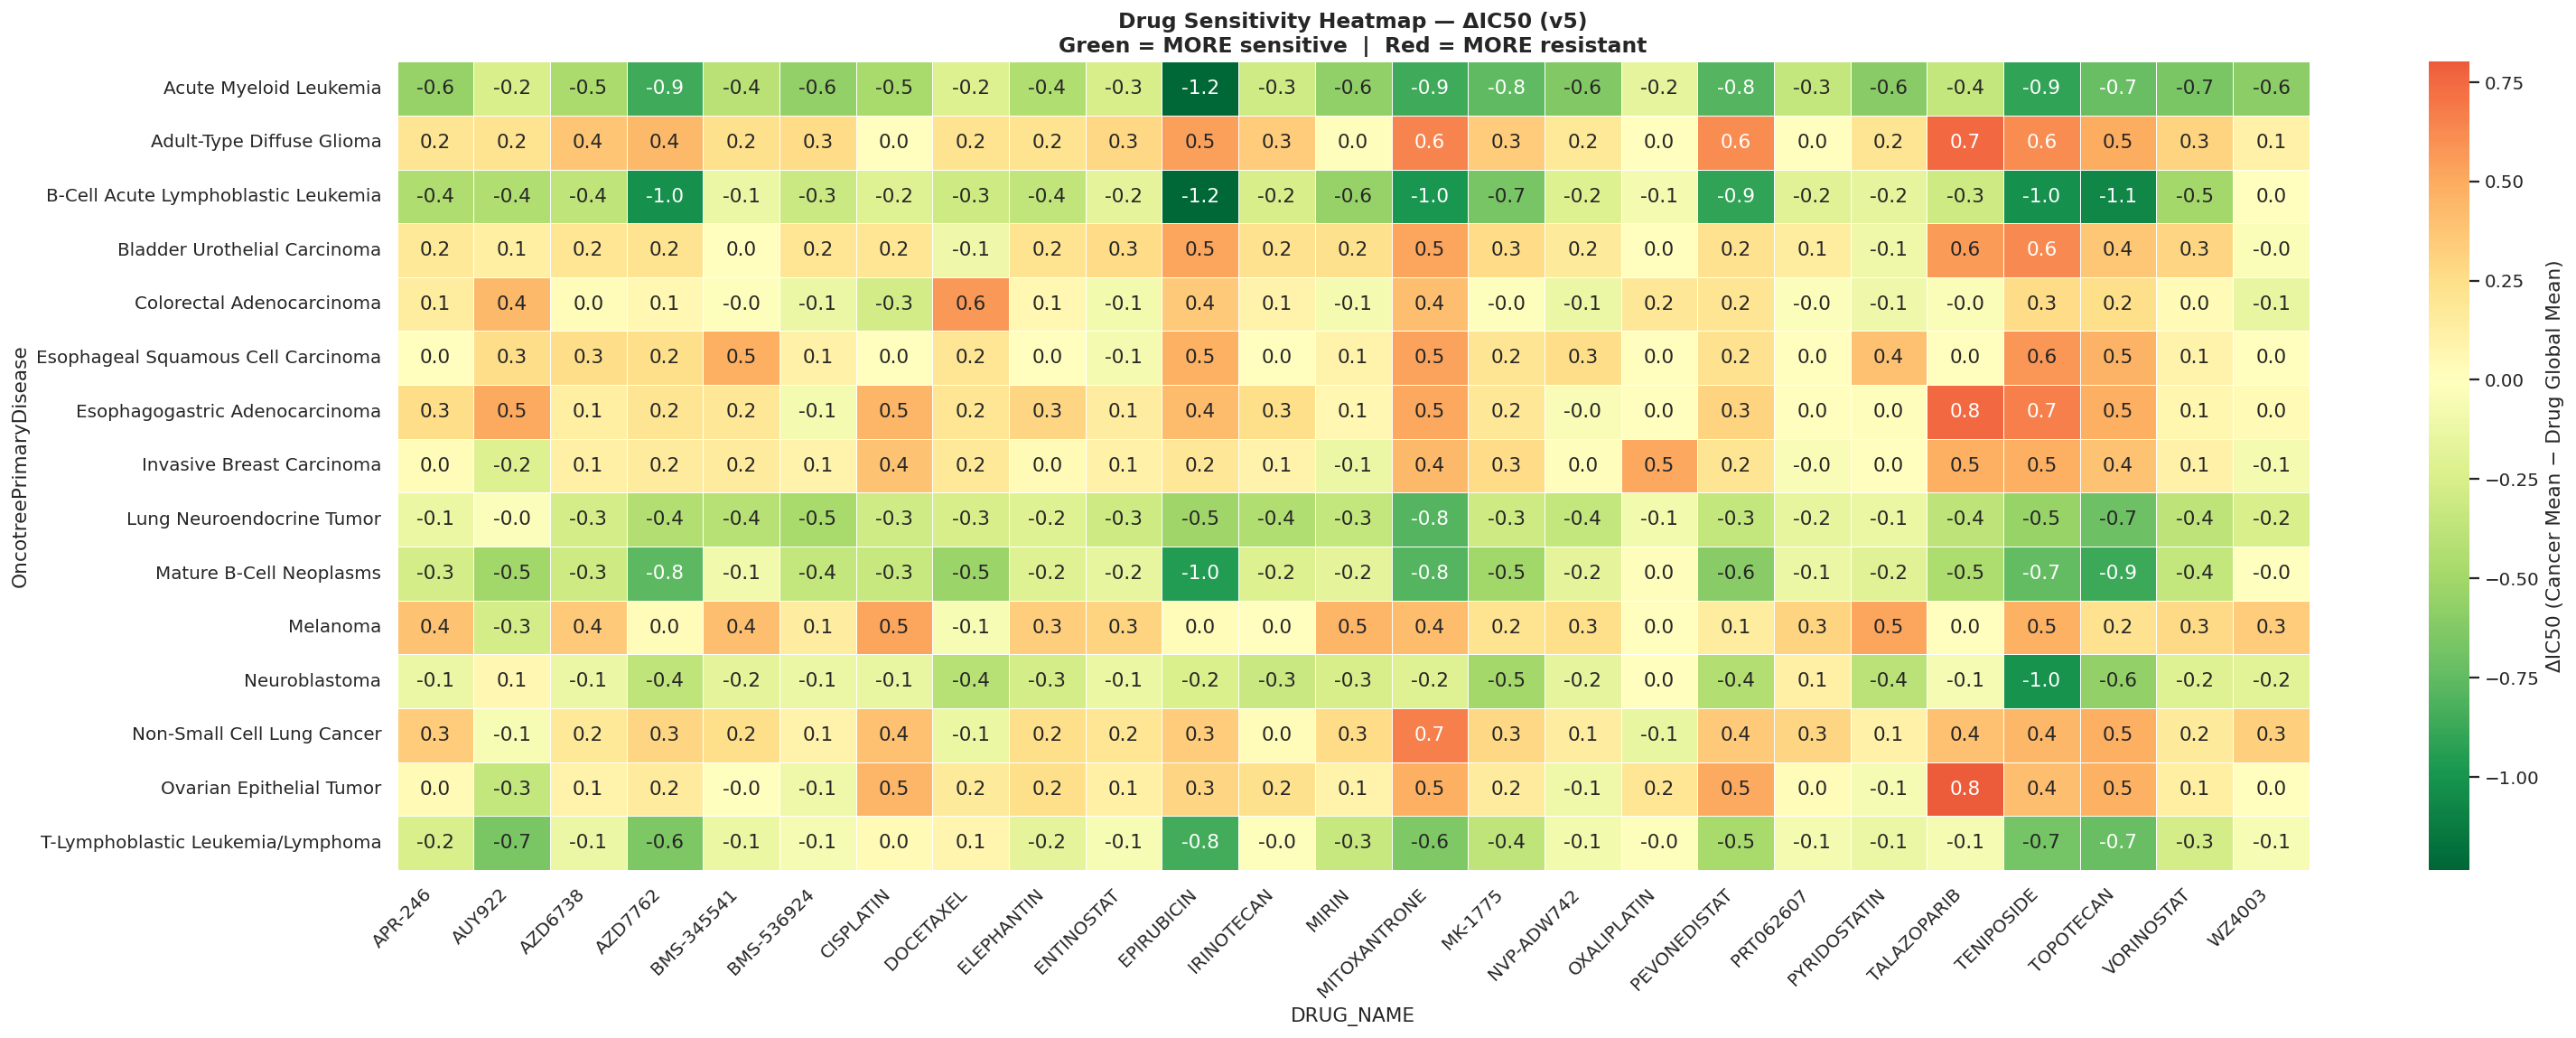


Top 3 predicted sensitive drugs per cancer type:
                                                                             OncotreePrimaryDisease    DRUG_NAME  mean_pred_ic50  mean_true_ic50  n_cell_lines
                                                                             Acute Myeloid Leukemia  VINBLASTINE       -5.553442       -5.793852             9
                                                                             Acute Myeloid Leukemia   BORTEZOMIB       -5.295890       -5.034787             9
                                                                             Acute Myeloid Leukemia DACTINOMYCIN       -4.949540       -4.878555             7
                                                                           Adrenocortical Carcinoma  VINBLASTINE       -5.457894       -5.626851             1
                                                                           Adrenocortical Carcinoma   BORTEZOMIB       -5.137073       -5.174633           

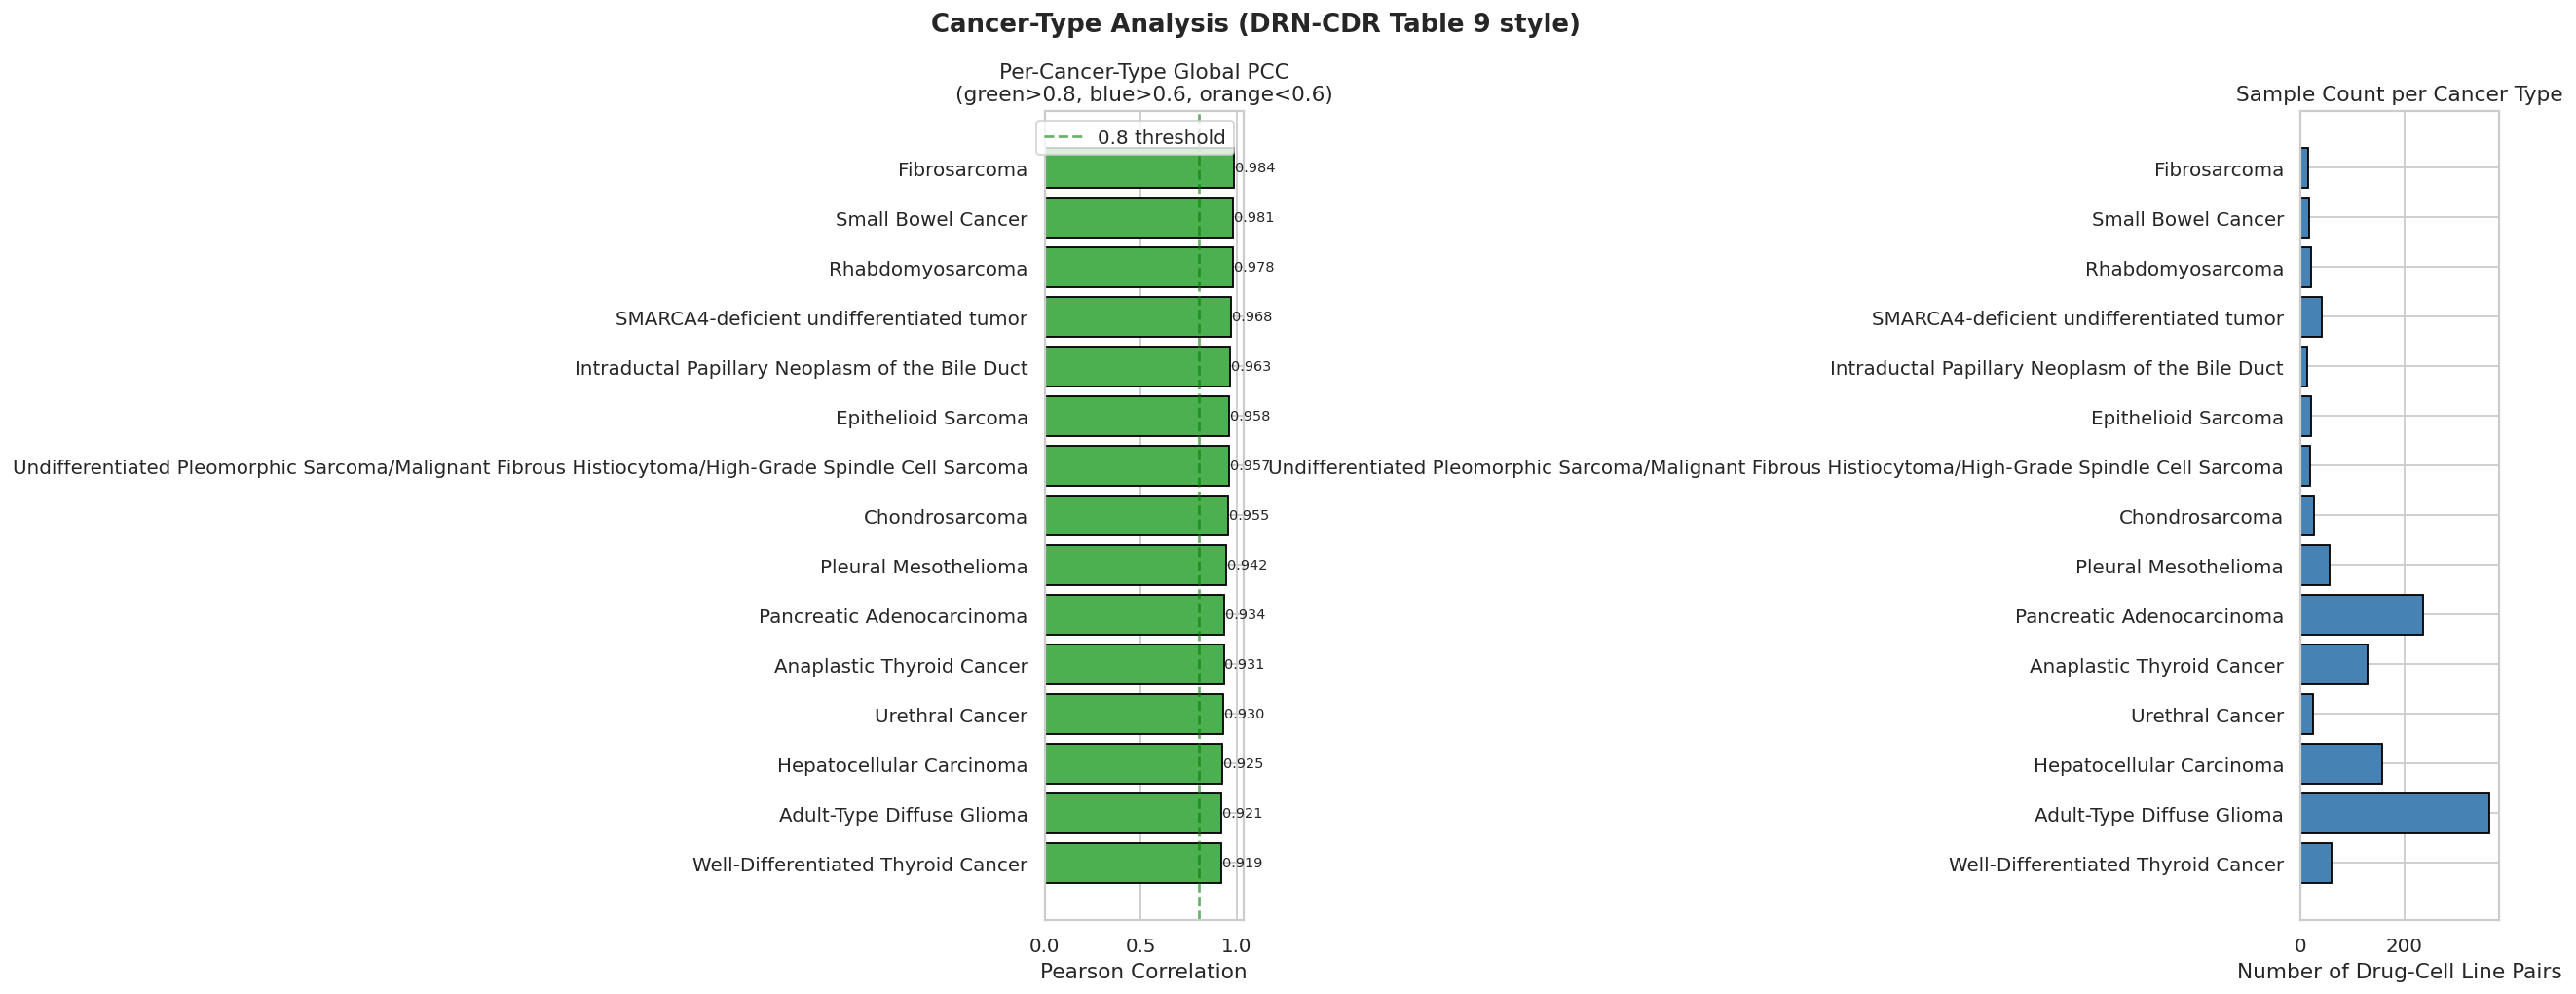


══════════════════════════════════════════════════════════════════════
  PIPELINE COMPLETE — OncoBridge v5
══════════════════════════════════════════════════════════════════════
  Global PCC:          0.9423
  Global Spearman:     0.9211
  Global R²:           0.8729
  RMSE (ln-IC50):      0.9750
  Avg Drug AUC:        0.6280
  Avg Drug AUPR:       0.6785  ← NEW metric
  Cold GlobalPCC:      0.0915  (DTLCDR SOTA: 0.6210)
══════════════════════════════════════════════════════════════════════

v5 improvements applied:
  ✓ Dual drug encoder: ChemBERTa(768→256) + MorganFP(2048→256) = 512-dim
  ✓ Modality dropout p=0.35 (raised from v4 0.20)
  ✓ AUPR metric added (DeepCDR & DRN-CDR standard)
  ✓ Per-drug scatter plots — top/bottom drugs (DRN-CDR Fig 6 style)
  ✓ Cancer-type PCC table (DRN-CDR Table 9 style)
  ✓ Drug ablation: No-ChemBERTa vs No-MorganFP (dual encoder validation)


In [14]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 13 — CANCER-TYPE ANALYSIS + DRUG RANKINGS
#  DRN-CDR Table 9 style: per-cancer-type PCC and top sensitive drugs.
#  Bug fix: mean_true_ic50 now uses 'ic50_value' (was PRED_IC50 in v3)
# ═══════════════════════════════════════════════════════════════════════
section('13. CANCER-TYPE ANALYSIS & DRUG RANKINGS')

all_ds = DrugResponseDataset(
    pd.concat([ic50_warm, ic50_cold]).drop_duplicates(['ModelID','DRUG_NAME']),
    all_cell_lines, mrna_arr, cnv_arr, mut_arr, meth_arr,
    DRUG_EMB_MATRIX, FP_MATRIX)
all_loader2 = DataLoader(all_ds, batch_size=CONFIG['batch_size']*2,
                         shuffle=False, num_workers=nw, pin_memory=True)
_, all_p, all_t, all_d = run_epoch(model, all_loader2, None, None, False)

all_recs = pd.concat([ic50_warm, ic50_cold]).drop_duplicates(
    ['ModelID','DRUG_NAME']).reset_index(drop=True)
assert len(all_recs) == len(all_p)
all_recs['PRED_IC50'] = all_p

# ── Per-cancer-type Pearson (DRN-CDR Table 9 style) ──────────────────────
cancer_pcc = []
for cancer, grp in all_recs.groupby('OncotreePrimaryDisease'):
    if len(grp) < 10: continue
    r, _ = pearsonr(grp['PRED_IC50'].values, grp['ic50_value'].values)
    cancer_pcc.append({'CancerType': cancer, 'PCC': round(r, 4), 'N_Pairs': len(grp)})

cancer_df = pd.DataFrame(cancer_pcc).sort_values('PCC', ascending=False)
print('\nPer-cancer-type Pearson PCC (DRN-CDR Table 9 style):')
print(cancer_df.to_string(index=False))

# ── Drug sensitivity heatmap ─────────────────────────────────────────────
drug_global_mean = all_recs.groupby('DRUG_NAME')['PRED_IC50'].mean()
all_recs['delta_ic50'] = all_recs.apply(
    lambda r: r['PRED_IC50'] - drug_global_mean[r['DRUG_NAME']], axis=1)

top_cancers    = all_recs['OncotreePrimaryDisease'].value_counts().head(15).index
top_drugs_warm = drug_df.head(25).index.tolist()

pivot = (all_recs[all_recs['OncotreePrimaryDisease'].isin(top_cancers) &
                  all_recs['DRUG_NAME'].isin(top_drugs_warm)]
         .groupby(['OncotreePrimaryDisease','DRUG_NAME'])['delta_ic50'].mean()
         .unstack(fill_value=0))

plt.figure(figsize=(24, 9))
sns.heatmap(pivot, cmap='RdYlGn_r', center=0,
            annot=True, fmt='.1f', linewidths=0.3,
            cbar_kws={'label': 'ΔIC50 (Cancer Mean − Drug Global Mean)'})
plt.title('Drug Sensitivity Heatmap — ΔIC50 (v5)\n'
          'Green = MORE sensitive  |  Red = MORE resistant',
          fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUT_DIR+'v5_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Per-cancer top drugs table (DRN-CDR Table 9 style) ───────────────────
drug_ranking = (all_recs.groupby(['OncotreePrimaryDisease','DRUG_NAME'])
                .agg(mean_pred_ic50 = ('PRED_IC50',    'mean'),
                     mean_true_ic50 = ('ic50_value',   'mean'),   # FIXED bug
                     n_cell_lines   = ('ModelID', 'nunique'))
                .reset_index())
top5 = (drug_ranking.sort_values(['OncotreePrimaryDisease','mean_pred_ic50'])
        .groupby('OncotreePrimaryDisease').head(3))
print('\nTop 3 predicted sensitive drugs per cancer type:')
print(top5.to_string(index=False))

# ── Cancer-type PCC bar chart ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Cancer-Type Analysis (DRN-CDR Table 9 style)', fontweight='bold')

top15_cancer = cancer_df.head(15)
colors_cancer = ['#4CAF50' if p > 0.8 else '#2196F3' if p > 0.6 else '#FF9800'
                 for p in top15_cancer['PCC']]
axes[0].barh(top15_cancer['CancerType'], top15_cancer['PCC'],
             color=colors_cancer, edgecolor='black')
axes[0].axvline(0.8, color='green', ls='--', alpha=0.6, label='0.8 threshold')
axes[0].set_xlabel('Pearson Correlation')
axes[0].invert_yaxis()
axes[0].set_title('Per-Cancer-Type Global PCC\n(green>0.8, blue>0.6, orange<0.6)')
axes[0].legend()
for i, (_, row) in enumerate(top15_cancer.iterrows()):
    axes[0].text(row['PCC']+0.005, i, f'{row["PCC"]:.3f}', va='center', fontsize=8)

# N samples per cancer type
axes[1].barh(top15_cancer['CancerType'], top15_cancer['N_Pairs'],
             color='steelblue', edgecolor='black')
axes[1].set_xlabel('Number of Drug-Cell Line Pairs')
axes[1].invert_yaxis()
axes[1].set_title('Sample Count per Cancer Type')

plt.tight_layout()
plt.savefig(OUT_DIR+'v5_cancer_type_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Save all outputs
all_recs.to_csv(OUT_DIR+'v5_all_predictions.csv', index=False)
cancer_df.to_csv(OUT_DIR+'v5_cancer_type_pcc.csv', index=False)
top5.to_csv(OUT_DIR+'v5_top_drugs_per_cancer.csv', index=False)

print('\n' + '═'*70)
print('  PIPELINE COMPLETE — OncoBridge v5')
print('═'*70)
print(f'  Global PCC:          {te_m["pearson"]:.4f}')
print(f'  Global Spearman:     {te_m["spearman"]:.4f}')
print(f'  Global R²:           {te_m["r2"]:.4f}')
print(f'  RMSE (ln-IC50):      {te_m["rmse"]:.4f}')
print(f'  Avg Drug AUC:        {te_m["avg_drug_auc"]:.4f}')
print(f'  Avg Drug AUPR:       {te_m["avg_drug_aupr"]:.4f}  ← NEW metric')
print(f'  Cold GlobalPCC:      {cs_m["pearson"]:.4f}  (DTLCDR SOTA: 0.6210)')
print('═'*70)
print('\nv5 improvements applied:')
print('  ✓ Dual drug encoder: ChemBERTa(768→256) + MorganFP(2048→256) = 512-dim')
print('  ✓ Modality dropout p=0.35 (raised from v4 0.20)')
print('  ✓ AUPR metric added (DeepCDR & DRN-CDR standard)')
print('  ✓ Per-drug scatter plots — top/bottom drugs (DRN-CDR Fig 6 style)')
print('  ✓ Cancer-type PCC table (DRN-CDR Table 9 style)')
print('  ✓ Drug ablation: No-ChemBERTa vs No-MorganFP (dual encoder validation)')
